# 0.0 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

## 0.1 Load Data

In [2]:
df_raw = pd.read_csv('../data/df_ready.csv')
df_raw.head(1)  

,Unnamed: 0,Date_imp,Date_imp_d,Cluster,Category_name,name,price,disc_price,merchant,condition,...,sourceURLs,weight,Date_imp_d.1,Day_n,month,month_n,day,Week_Number,Zscore_1,price_std
0,4,2017-12-14 06:00:00,2017/12/14,35,"speaker, portable, bluetooth",Boytone - 2500W 2.1-Ch. Home Theater System - ...,69.0,64.99,Walmart.com,New,...,https://www.walmart.com/ip/BOYTONE-BT210FB-BLA...,14 pounds,2017/12/14,Thursday,12,December,14,50,0.001525,3.880725


## 0.2 Clean Trash Data


In [3]:
df_raw.head(1)

,Unnamed: 0,Date_imp,Date_imp_d,Cluster,Category_name,name,price,disc_price,merchant,condition,...,sourceURLs,weight,Date_imp_d.1,Day_n,month,month_n,day,Week_Number,Zscore_1,price_std
0,4,2017-12-14 06:00:00,2017/12/14,35,"speaker, portable, bluetooth",Boytone - 2500W 2.1-Ch. Home Theater System - ...,69.0,64.99,Walmart.com,New,...,https://www.walmart.com/ip/BOYTONE-BT210FB-BLA...,14 pounds,2017/12/14,Thursday,12,December,14,50,0.001525,3.880725


In [4]:
df_raw = df_raw.drop(columns={'Unnamed: 0', 'Date_imp', 'Cluster', 'condition', 'sourceURLs', 'Date_imp_d.1', 'Zscore_1', 'price_std', 'imageURLs', 'shipping', 'weight', 'currency'})

In [5]:
df_raw.columns

Index(['Date_imp_d', 'Category_name', 'name', 'price', 'disc_price',
       'merchant', 'Disc_percentage', 'isSale', 'Imp_count', 'brand',
       'p_description', 'dateAdded', 'dateSeen', 'dateUpdated', 'manufacturer',
       'Day_n', 'month', 'month_n', 'day', 'Week_Number'],
      dtype='object')

# 1.0 Descrição dos dados

In [6]:
df1 = df_raw.copy()

## 1.1 Rename Columns

In [7]:
cols_name =['date_imp', 'category_name', 'name', 'price', 'disc_price',
       'merchant', 'disc_percentage', 'is_sale', 'imp_count', 'brand',
       'p_description', 'date_added', 'date_seen', 'date_updated', 'manufacturer',
       'day_n', 'month', 'month_n', 'day', 'week_number']
df1.columns = cols_name

## 1.2 Data Dimension

In [8]:
print(f'Number of rows: {df1.shape[0]}')
print(f'Number of columns: {df1.shape[1]}')

Number of rows: 23151
Number of columns: 20


## 1.3 Data Types

In [9]:
df1.head(1)

,date_imp,category_name,name,price,disc_price,merchant,disc_percentage,is_sale,imp_count,brand,p_description,date_added,date_seen,date_updated,manufacturer,day_n,month,month_n,day,week_number
0,2017/12/14,"speaker, portable, bluetooth",Boytone - 2500W 2.1-Ch. Home Theater System - ...,69.0,64.99,Walmart.com,0.06,Yes,1,Boytone,"Stereos,Portable Bluetooth Speakers,TV, Video ...",2015-05-18T14:14:56Z,2017-12-14T06:00:00Z,2018-06-13T19:39:02Z,Boytone,Thursday,12,December,14,50


In [10]:
df1.dtypes

date_imp            object
category_name       object
name                object
price              float64
disc_price         float64
merchant            object
disc_percentage    float64
is_sale             object
imp_count            int64
brand               object
p_description       object
date_added          object
date_seen           object
date_updated        object
manufacturer        object
day_n               object
month                int64
month_n             object
day                  int64
week_number          int64
dtype: object

## 1.4 Check NA

In [11]:
df1.isna().sum()

date_imp               0
category_name          0
name                   0
price                  0
disc_price             0
merchant               0
disc_percentage        0
is_sale                0
imp_count              0
brand                  0
p_description          0
date_added             0
date_seen              0
date_updated           0
manufacturer       10639
day_n                  0
month                  0
month_n                0
day                    0
week_number            0
dtype: int64

## 1.5 Replace NA

## 1.6 Change dtypes

In [12]:
df1['date_imp'] = pd.to_datetime( df1['date_imp'])
df1['date_added'] = pd.to_datetime( df1['date_added'])
#df1['date_seen'] = pd.to_datetime( df1['date_seen'])
df1['date_updated'] = pd.to_datetime( df1['date_updated'])
df1.dtypes

date_imp                datetime64[ns]
category_name                   object
name                            object
price                          float64
disc_price                     float64
merchant                        object
disc_percentage                float64
is_sale                         object
imp_count                        int64
brand                           object
p_description                   object
date_added         datetime64[ns, UTC]
date_seen                       object
date_updated       datetime64[ns, UTC]
manufacturer                    object
day_n                           object
month                            int64
month_n                         object
day                              int64
week_number                      int64
dtype: object

## 1.7 Descriptive Statistics

In [13]:
num_attributes = df1.select_dtypes( include = ['int64', 'float64'])
cat_attributes = df1.select_dtypes( exclude = ['int64', 'float64', 'datetime64[ns]'])

### 1.7.1 Numerical Attributes

In [14]:
# Central tendency - mean, median
ct1 = pd.DataFrame( num_attributes.apply( np.mean )).T
ct2 = pd.DataFrame( num_attributes.apply( np.median )).T

# dispersion - std, min, max, range, skew, kurtosis
d1 = pd.DataFrame( num_attributes.apply( np.std )).T
d2 = pd.DataFrame( num_attributes.apply( min )).T
d3 = pd.DataFrame( num_attributes.apply( max )).T
d4 = pd.DataFrame( num_attributes.apply( lambda x: x.max() - x.min() )).T
d5 = pd.DataFrame( num_attributes.apply( lambda x: x.skew() )).T
d6 = pd.DataFrame( num_attributes.apply( lambda x: x.kurtosis() )).T

#concat
m = pd.concat( [d2, d3, d4, ct1, ct2, d1, d5, d6] ).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis'] 
m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,price,1.0,10879.95,10878.95,513.037803,199.99,859.091448,4.595160,34.411146
1,disc_price,1.0,10879.95,10878.95,494.104295,199.00,808.571509,4.748349,39.612839
2,disc_percentage,0.0,0.80,0.80,0.016933,0.00,0.077847,5.217632,28.754920
3,imp_count,1.0,31.00,30.00,6.560926,5.00,5.403049,1.286351,1.639569
4,month,1.0,12.00,11.00,7.651030,8.00,2.592787,-0.099417,-0.628859
5,day,1.0,31.00,30.00,15.693879,16.00,9.681413,0.032258,-1.331838
6,week_number,1.0,51.00,50.00,31.342750,32.00,11.316253,-0.266980,-0.648027


### 1.7.2 Categorical Attributes

In [15]:
cat_attributes.head(1)

,category_name,name,merchant,is_sale,brand,p_description,date_added,date_seen,date_updated,manufacturer,day_n,month_n
0,"speaker, portable, bluetooth",Boytone - 2500W 2.1-Ch. Home Theater System - ...,Walmart.com,Yes,Boytone,"Stereos,Portable Bluetooth Speakers,TV, Video ...",2015-05-18 14:14:56+00:00,2017-12-14T06:00:00Z,2018-06-13 19:39:02+00:00,Boytone,Thursday,December


# 2.0 Análise Exploratória dos Dados

In [16]:
df2 = df1.copy()
df2.head(1)

,date_imp,category_name,name,price,disc_price,merchant,disc_percentage,is_sale,imp_count,brand,p_description,date_added,date_seen,date_updated,manufacturer,day_n,month,month_n,day,week_number
0,2017-12-14,"speaker, portable, bluetooth",Boytone - 2500W 2.1-Ch. Home Theater System - ...,69.0,64.99,Walmart.com,0.06,Yes,1,Boytone,"Stereos,Portable Bluetooth Speakers,TV, Video ...",2015-05-18 14:14:56+00:00,2017-12-14T06:00:00Z,2018-06-13 19:39:02+00:00,Boytone,Thursday,12,December,14,50


Qual o comerciante que mais vendeu?

Qual a categoria que mais vendeu?

Qual a marca que mais vendeu?

Quais dias da semana que mais vendem?

Quais meses que mais vendem?

Quais semanas há mais vendas?

## 2.1 Comerciante que mais vende

<AxesSubplot:xlabel='merchant', ylabel='date_imp'>

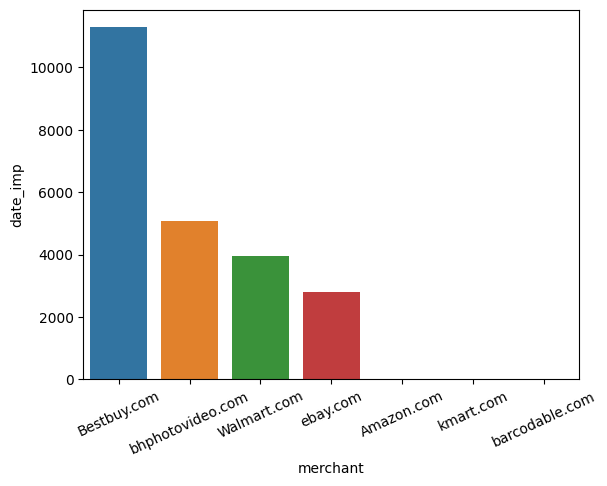

In [17]:
aux1 = df2[['date_imp', 'merchant']].groupby('merchant').count().sort_values(by='date_imp', ascending=False).reset_index()
plt.xticks(rotation =25)
sns.barplot(data=aux1, x="merchant", y="date_imp")

In [18]:
#seleção das lojas
df_best    = df2[df2['merchant']=='Bestbuy.com']
df_bh      = df2[df2['merchant']=='bhphotovideo.com']
df_walmart = df2[df2['merchant']=='Walmart.com']
df_ebay    = df2[df2['merchant']=='ebay.com']

## 2.2 Categorias mais vendidas 

### 2.2.1 Categorias mais vendidas no geral

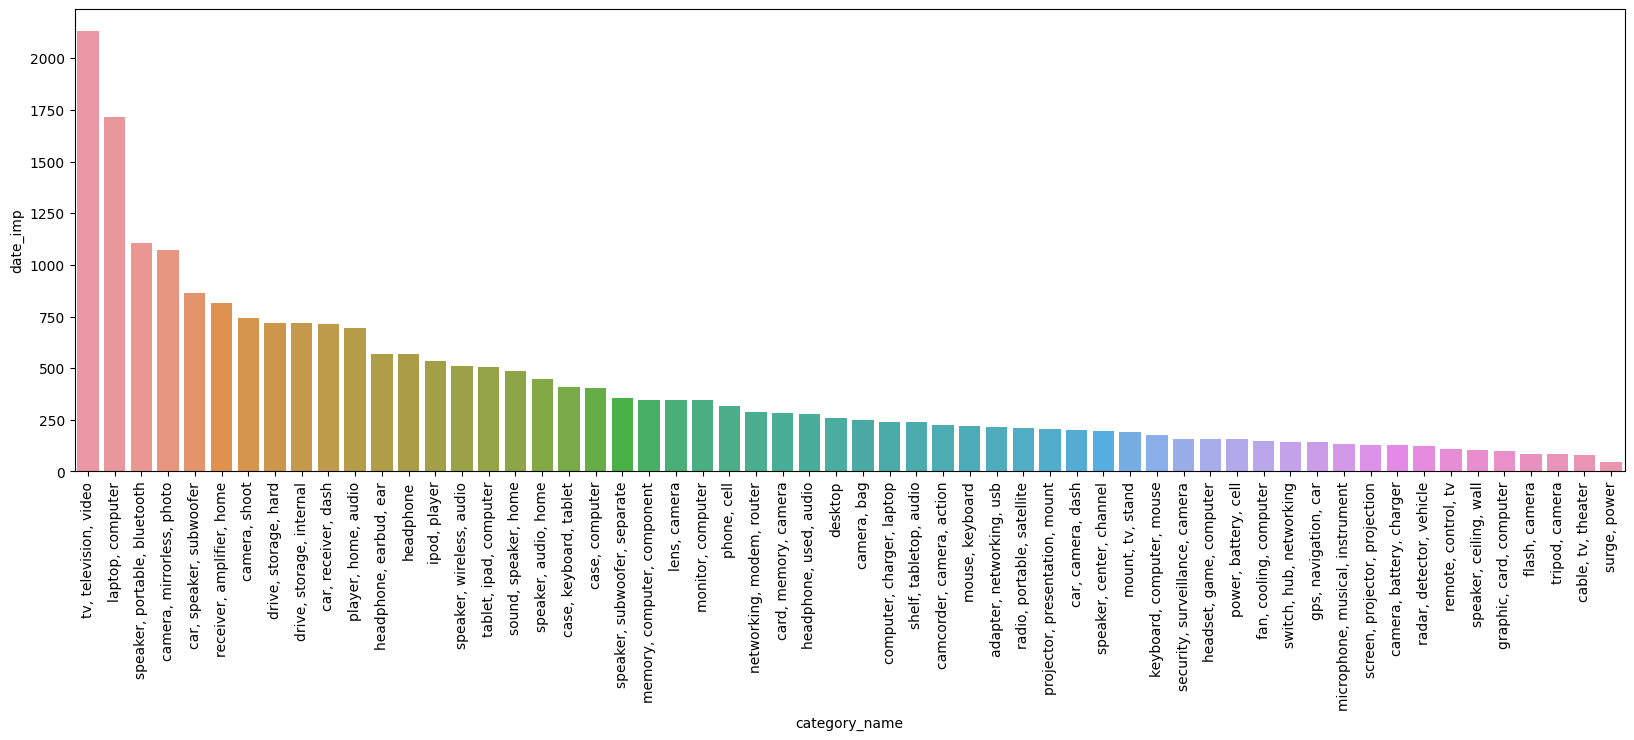

In [19]:
aux2 = df2[['date_imp', 'category_name']].groupby('category_name').count().sort_values(by='date_imp', ascending=False).reset_index()
plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
sns.barplot(data=aux2, x="category_name", y="date_imp");

### 2.2.2 Categorias mais vendidas por loja

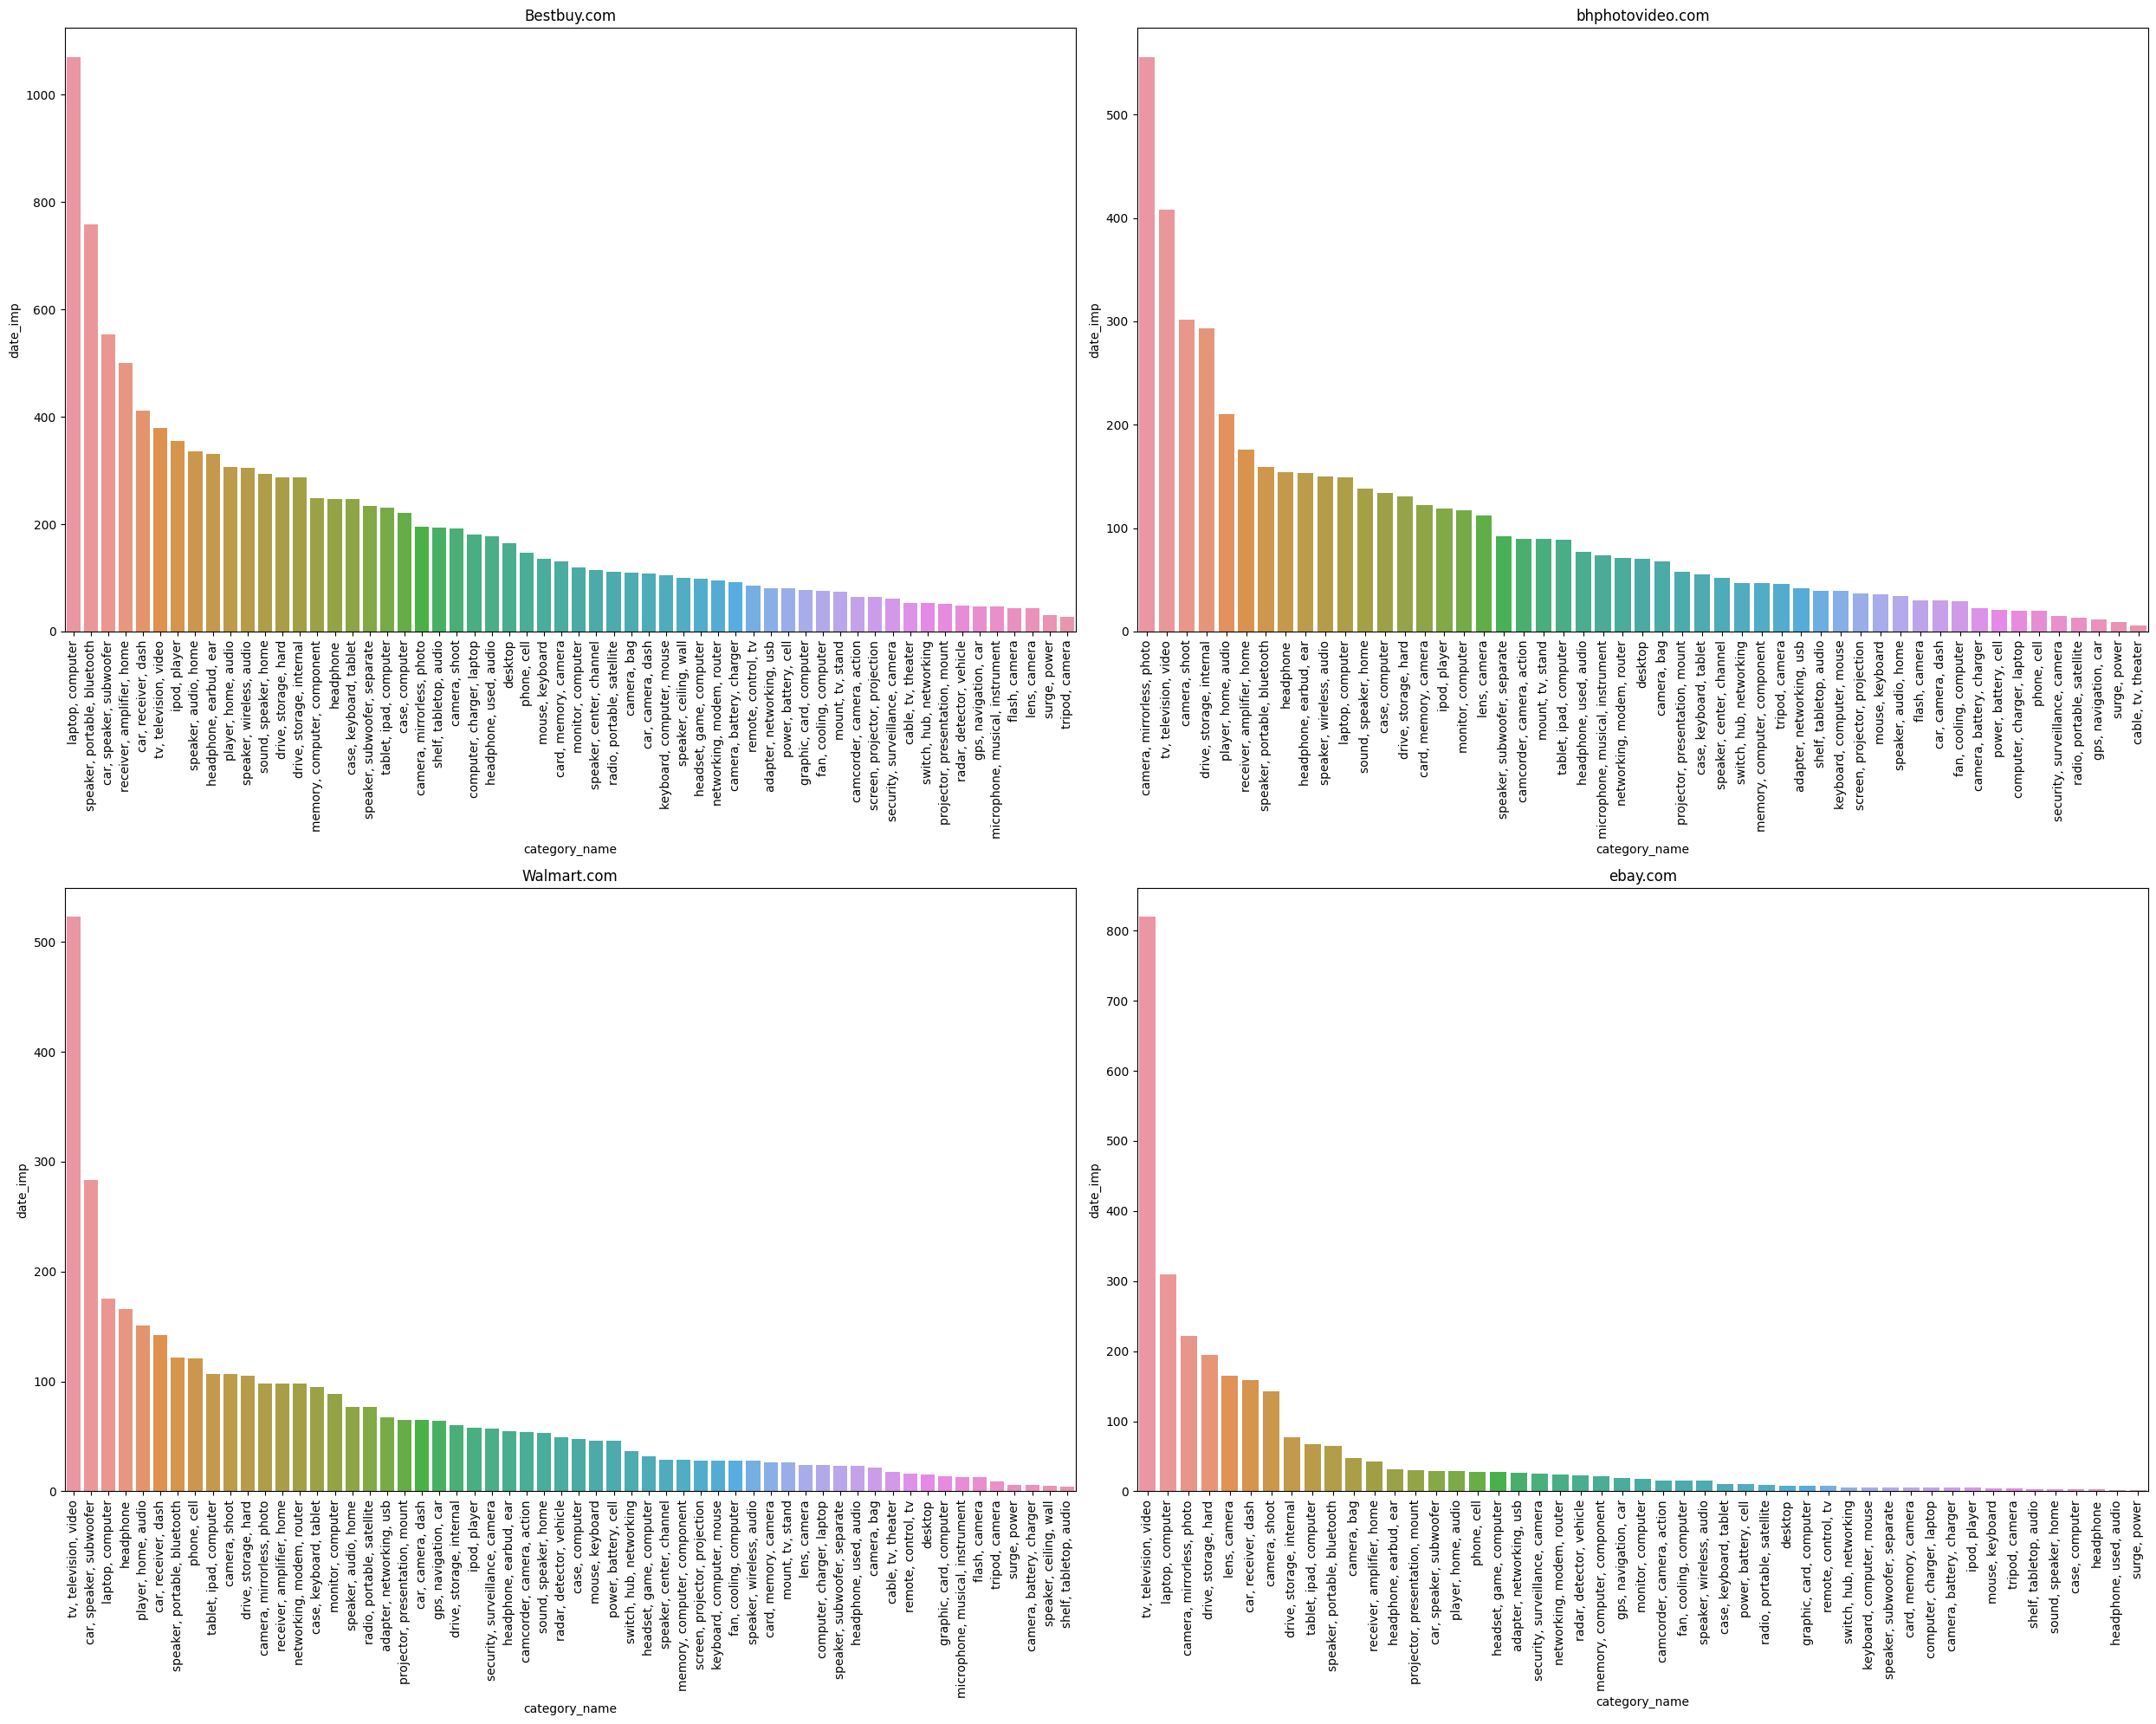

In [20]:
plt.figure(figsize=(25, 20))
plt.subplot(2,2,1)
aux3 = df_best[['date_imp', 'category_name']].groupby('category_name').count().sort_values(by='date_imp', ascending=False).reset_index()
#plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
plt.title("Bestbuy.com")
sns.barplot(data=aux3, x="category_name", y="date_imp");



plt.subplot(2,2,2)
aux4 = df_bh[['date_imp', 'category_name']].groupby('category_name').count().sort_values(by='date_imp', ascending=False).reset_index()
#plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
plt.title("bhphotovideo.com")
sns.barplot(data=aux4, x="category_name", y="date_imp");



plt.subplot(2,2,3)
aux5 = df_walmart[['date_imp', 'category_name']].groupby('category_name').count().sort_values(by='date_imp', ascending=False).reset_index()
#plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
plt.title("Walmart.com")
sns.barplot(data=aux5, x="category_name", y="date_imp");



plt.subplot(2,2,4)
aux6 = df_ebay[['date_imp', 'category_name']].groupby('category_name').count().sort_values(by='date_imp', ascending=False).reset_index()
#plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
plt.title("ebay.com")
sns.barplot(data=aux6, x="category_name", y="date_imp");

plt.tight_layout()

## 2.3 Marcas mais vendidas 

### 2.3.1 Marcas mais vendidas no geral

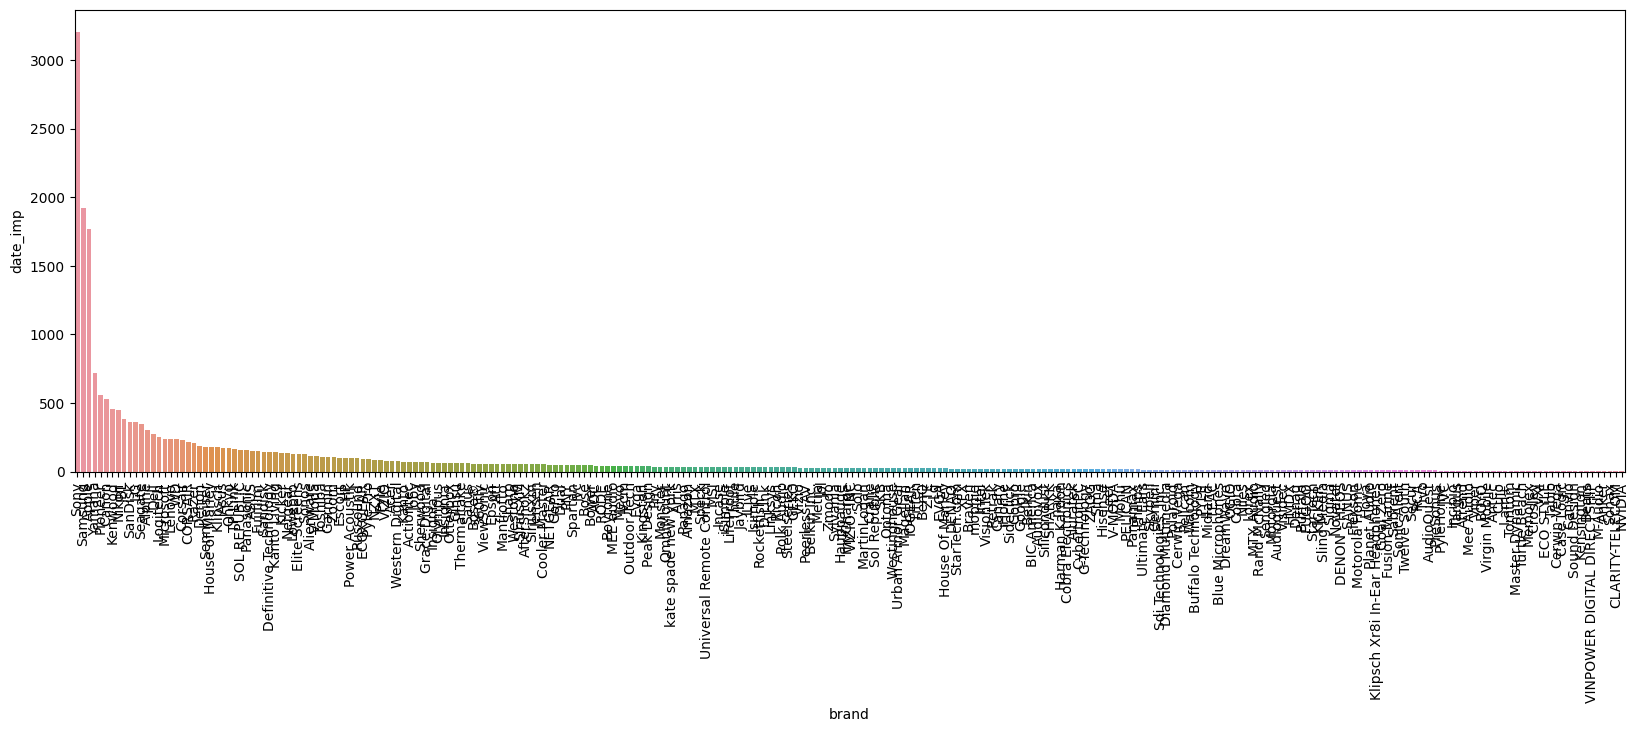

In [21]:
aux2 = df2[['date_imp', 'brand']].groupby('brand').count().sort_values(by='date_imp', ascending=False).reset_index()
plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
sns.barplot(data=aux2, x="brand", y="date_imp");

### 2.3.2 Marcas mais vendidas por loja

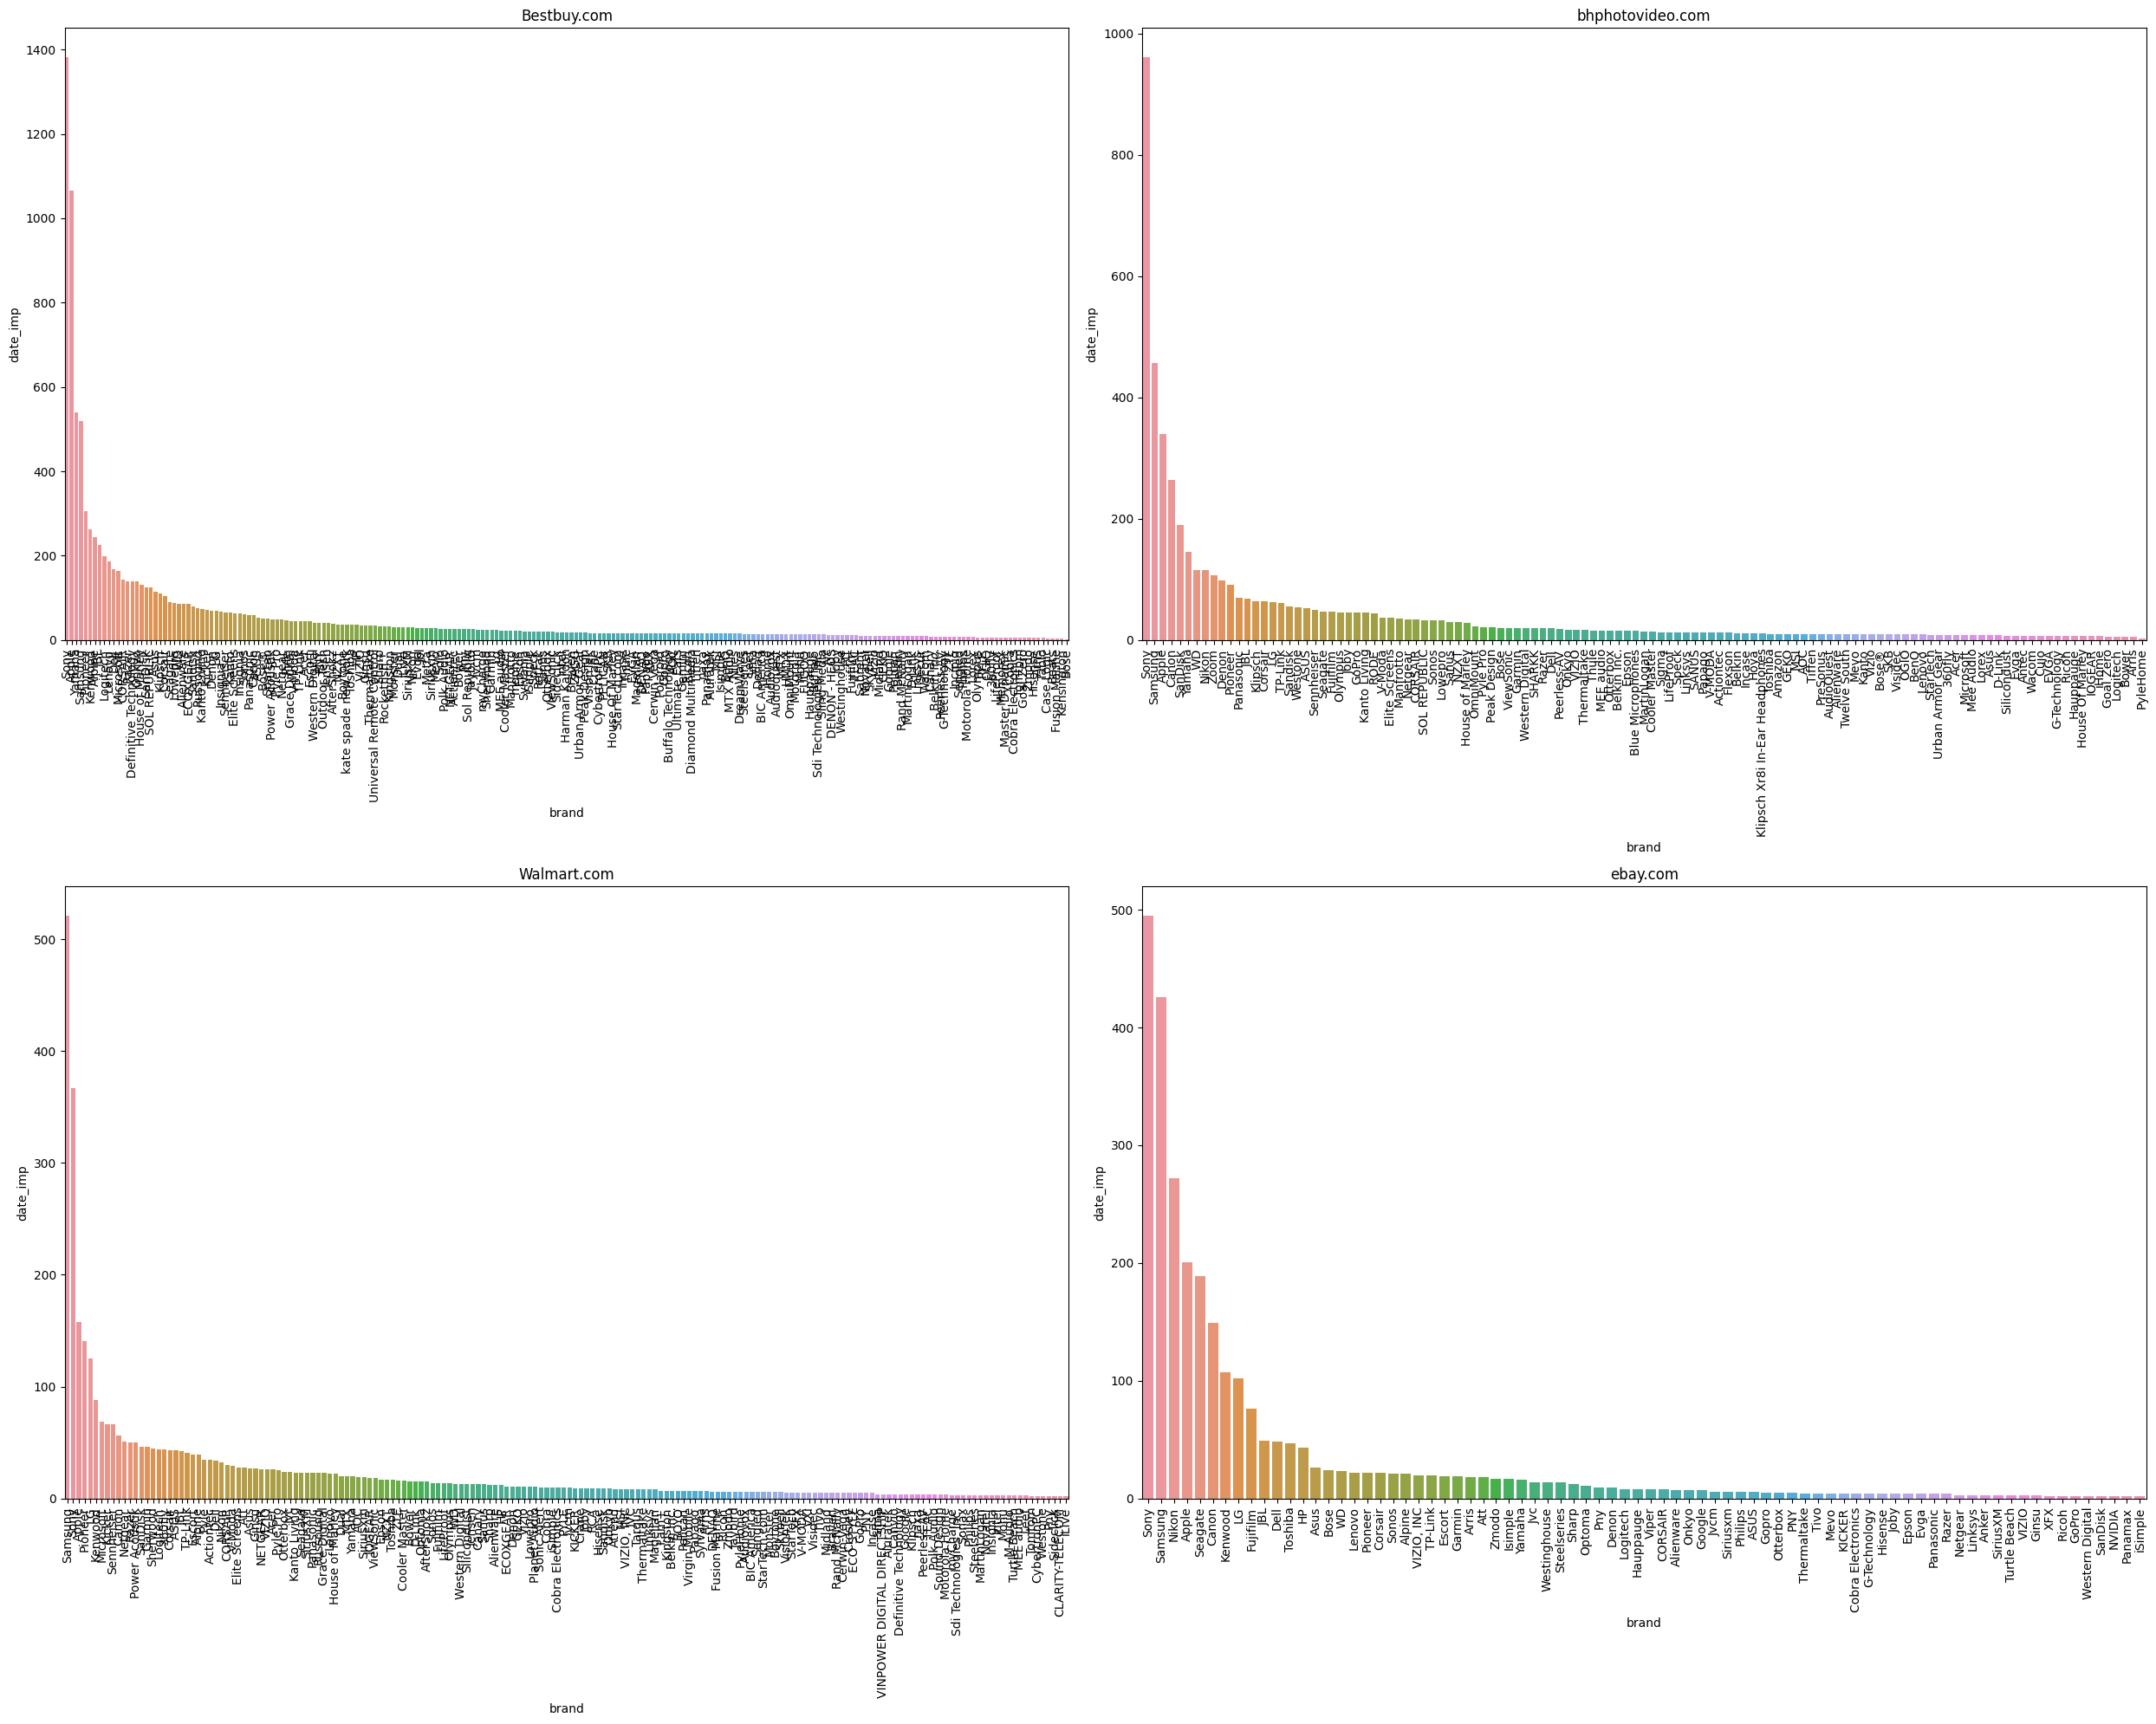

In [22]:
plt.figure(figsize=(25, 20))
plt.subplot(2,2,1)
aux3 = df_best[['date_imp', 'brand']].groupby('brand').count().sort_values(by='date_imp', ascending=False).reset_index()
#plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
plt.title("Bestbuy.com")
sns.barplot(data=aux3, x="brand", y="date_imp");



plt.subplot(2,2,2)
aux4 = df_bh[['date_imp', 'brand']].groupby('brand').count().sort_values(by='date_imp', ascending=False).reset_index()
#plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
plt.title("bhphotovideo.com")
sns.barplot(data=aux4, x="brand", y="date_imp");



plt.subplot(2,2,3)
aux5 = df_walmart[['date_imp', 'brand']].groupby('brand').count().sort_values(by='date_imp', ascending=False).reset_index()
#plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
plt.title("Walmart.com")
sns.barplot(data=aux5, x="brand", y="date_imp");



plt.subplot(2,2,4)
aux6 = df_ebay[['date_imp', 'brand']].groupby('brand').count().sort_values(by='date_imp', ascending=False).reset_index()
#plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
plt.title("ebay.com")
sns.barplot(data=aux6, x="brand", y="date_imp");

plt.tight_layout()

## 2.4 Dias que mais vendem

### 2.4.1 Dias que mais vendem no geral

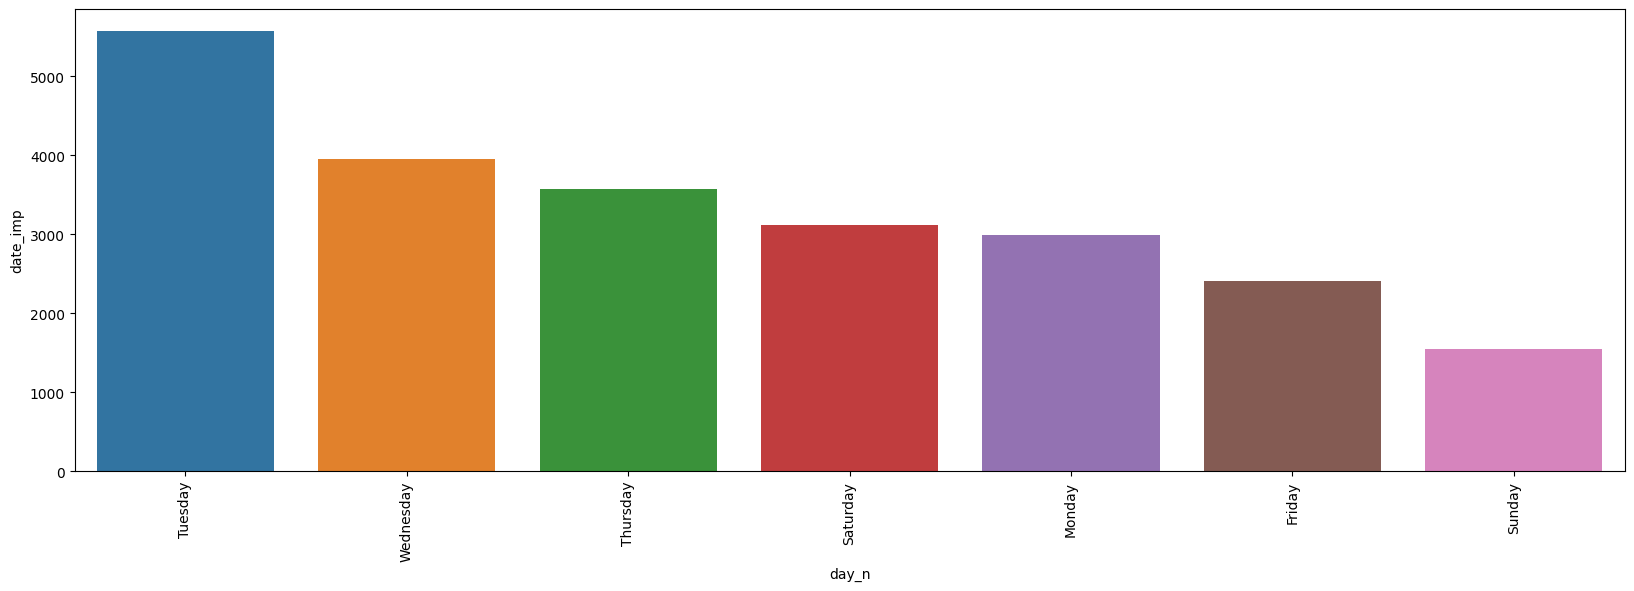

In [23]:
aux2 = df2[['date_imp', 'day_n']].groupby('day_n').count().sort_values(by='date_imp', ascending=False).reset_index()
plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
sns.barplot(data=aux2, x="day_n", y="date_imp");

### 2.4.2 Dias que mais vendem por loja

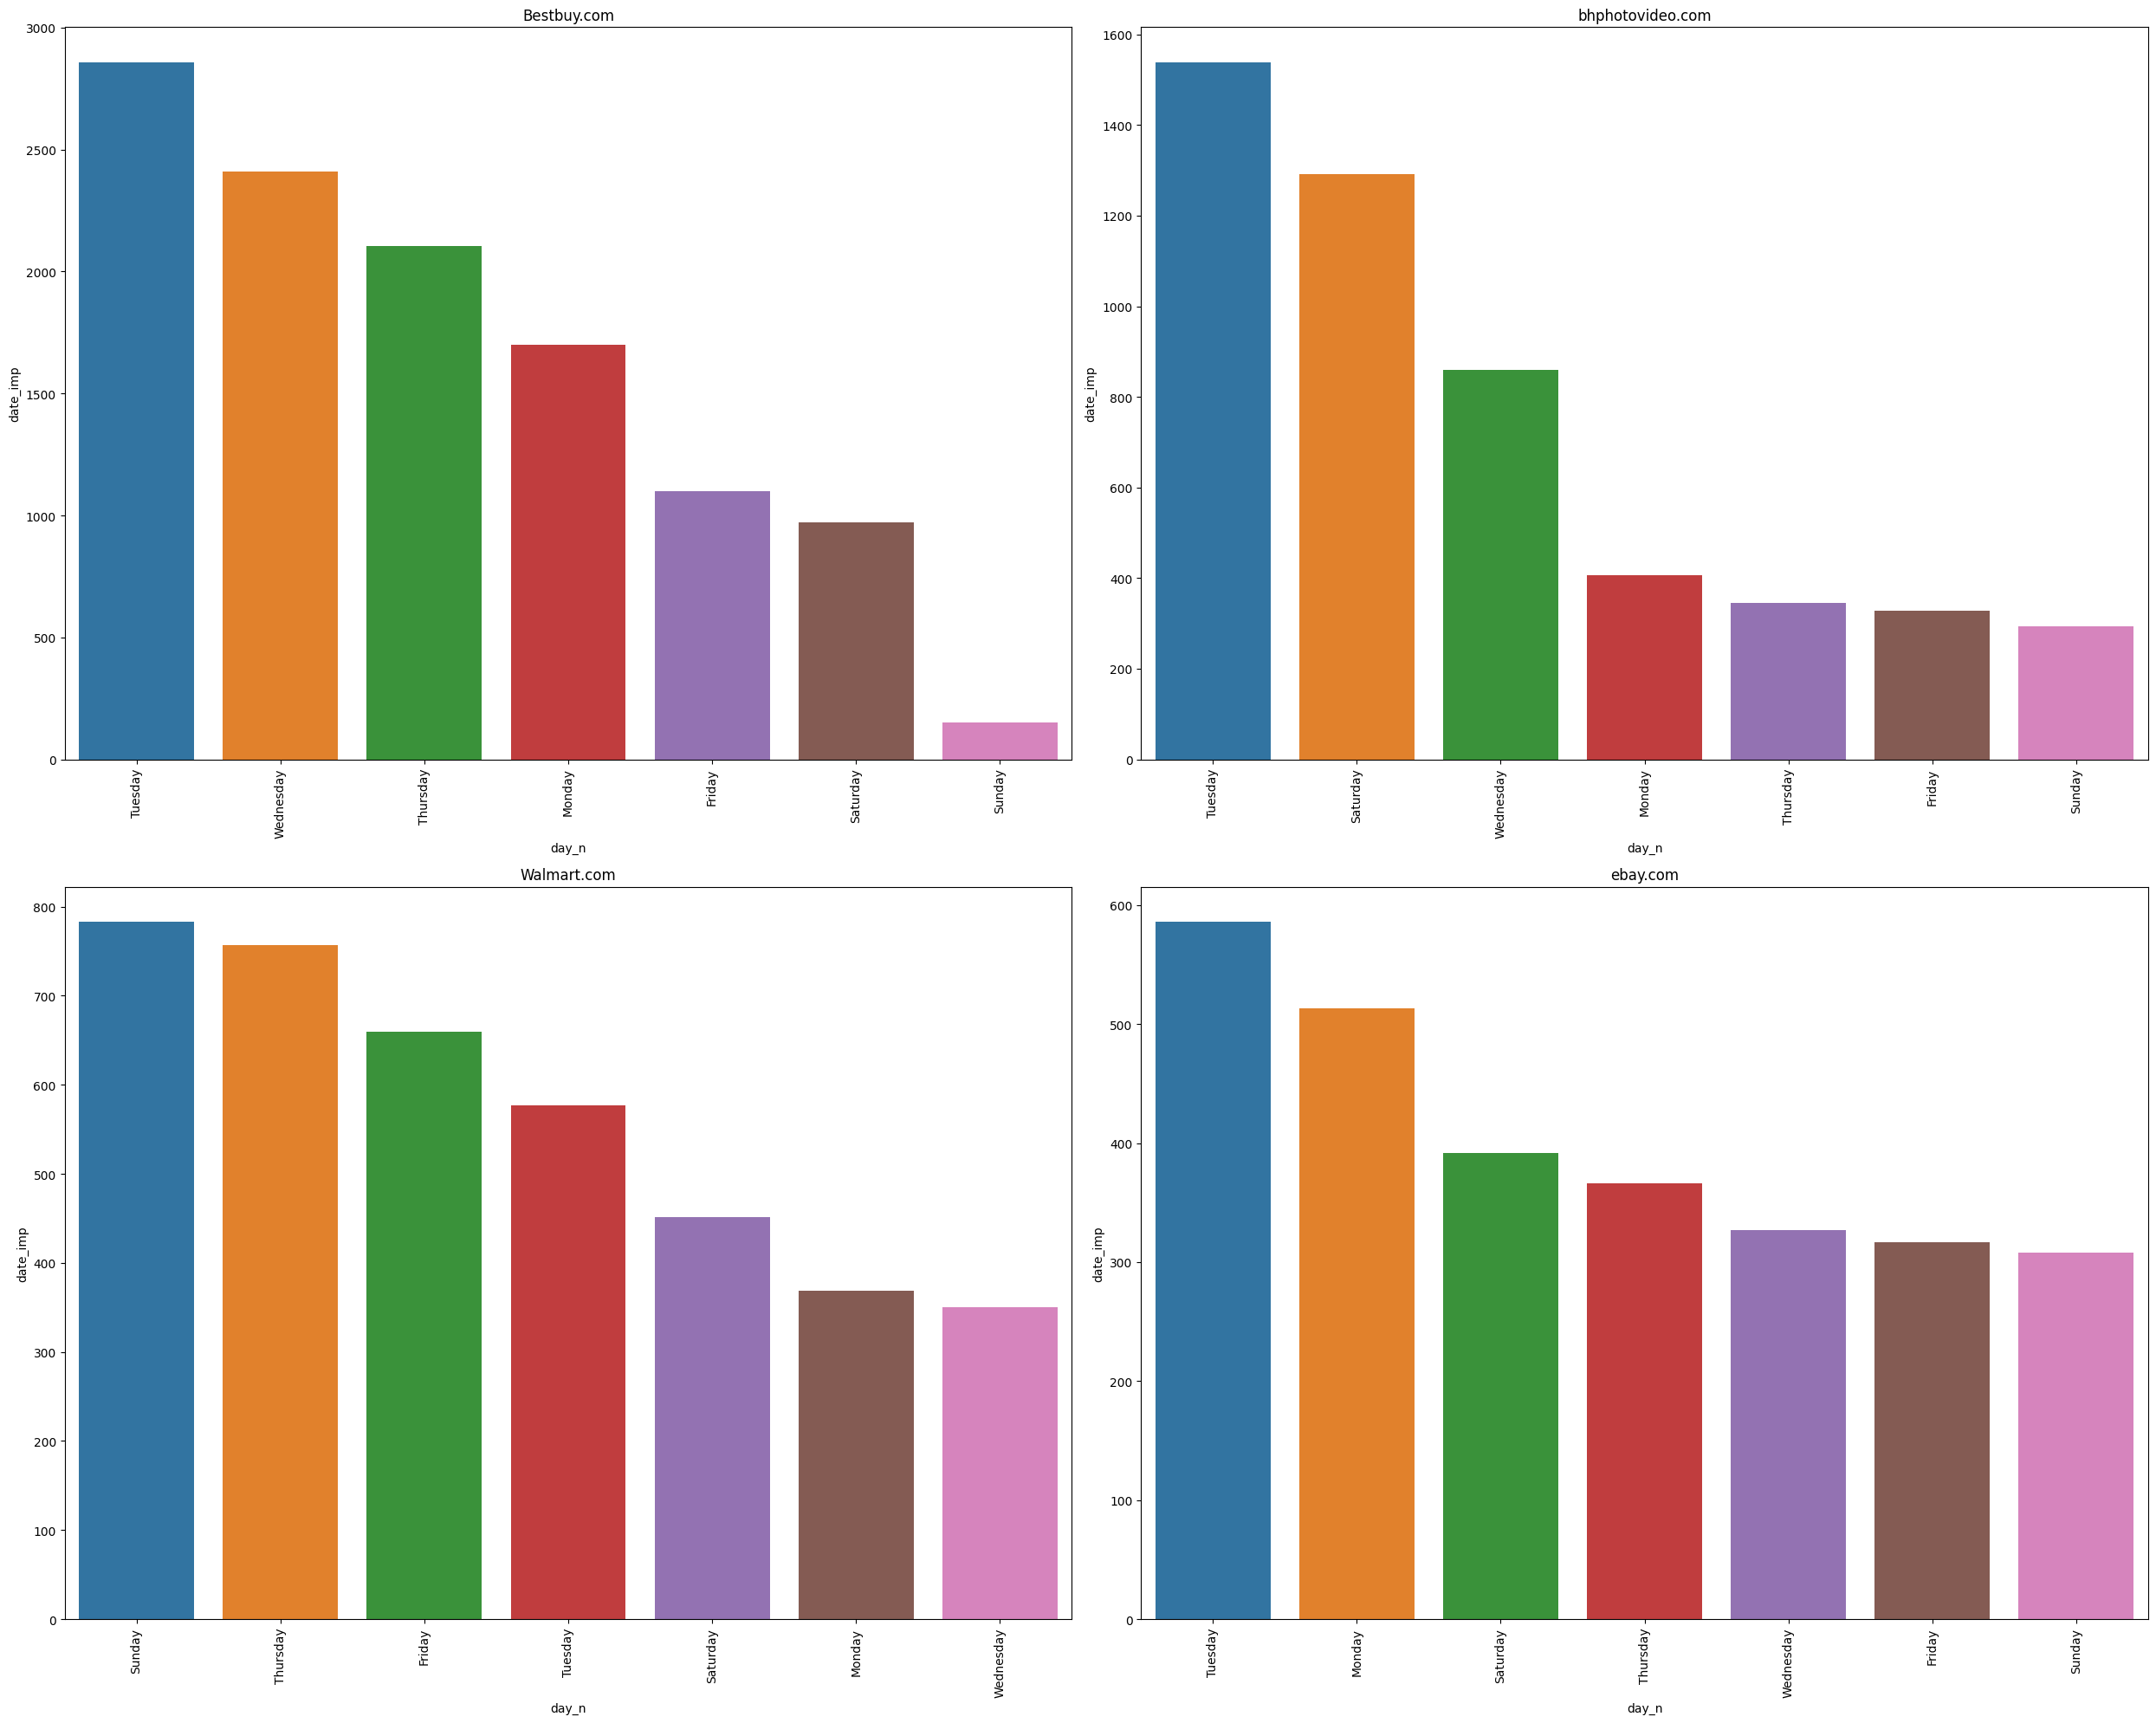

In [24]:
plt.figure(figsize=(25, 20))
plt.subplot(2,2,1)
aux3 = df_best[['date_imp', 'day_n']].groupby('day_n').count().sort_values(by='date_imp', ascending=False).reset_index()
#plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
plt.title("Bestbuy.com")
sns.barplot(data=aux3, x="day_n", y="date_imp");



plt.subplot(2,2,2)
aux4 = df_bh[['date_imp', 'day_n']].groupby('day_n').count().sort_values(by='date_imp', ascending=False).reset_index()
#plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
plt.title("bhphotovideo.com")
sns.barplot(data=aux4, x="day_n", y="date_imp");



plt.subplot(2,2,3)
aux5 = df_walmart[['date_imp', 'day_n']].groupby('day_n').count().sort_values(by='date_imp', ascending=False).reset_index()
#plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
plt.title("Walmart.com")
sns.barplot(data=aux5, x="day_n", y="date_imp");



plt.subplot(2,2,4)
aux6 = df_ebay[['date_imp', 'day_n']].groupby('day_n').count().sort_values(by='date_imp', ascending=False).reset_index()
#plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
plt.title("ebay.com")
sns.barplot(data=aux6, x="day_n", y="date_imp");

plt.tight_layout()

## 2.5 Semanas que mais vendem

### 2.5.1 Semanas que mais vendem no geral

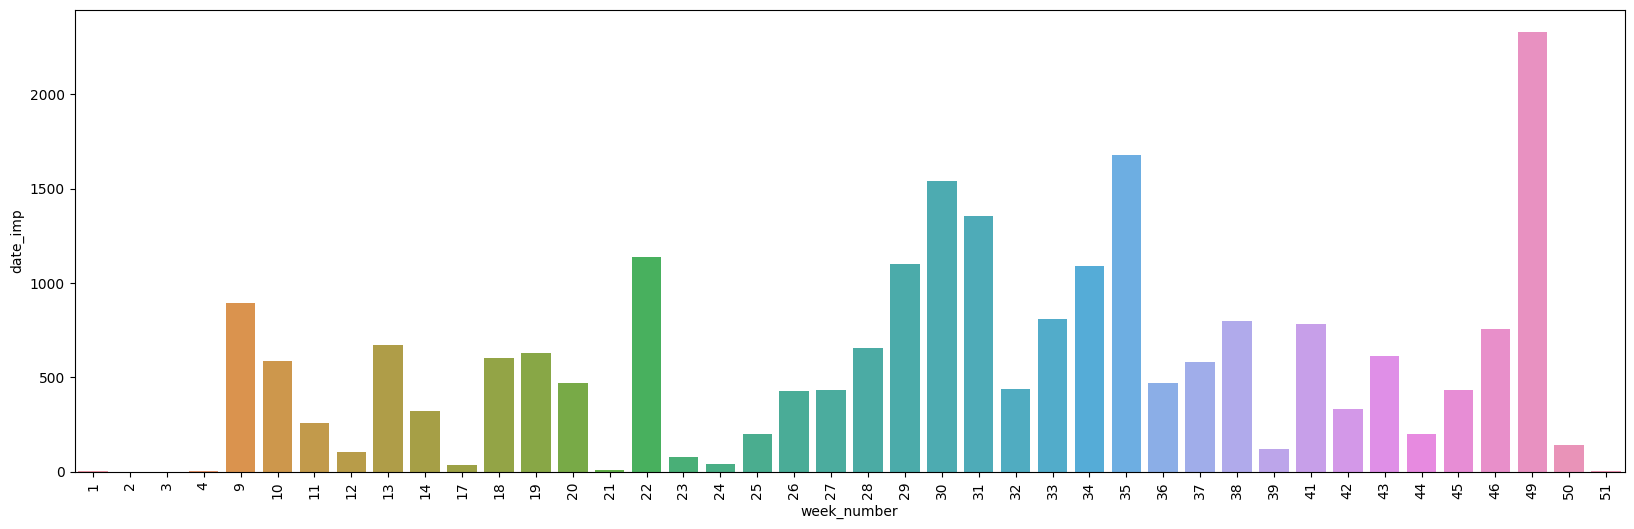

In [25]:
aux2 = df2[['date_imp', 'week_number']].groupby('week_number').count().sort_values(by='date_imp', ascending=False).reset_index()
plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
sns.barplot(data=aux2, x="week_number", y="date_imp");

### 2.5.2 Semanas que mais vendem por loja

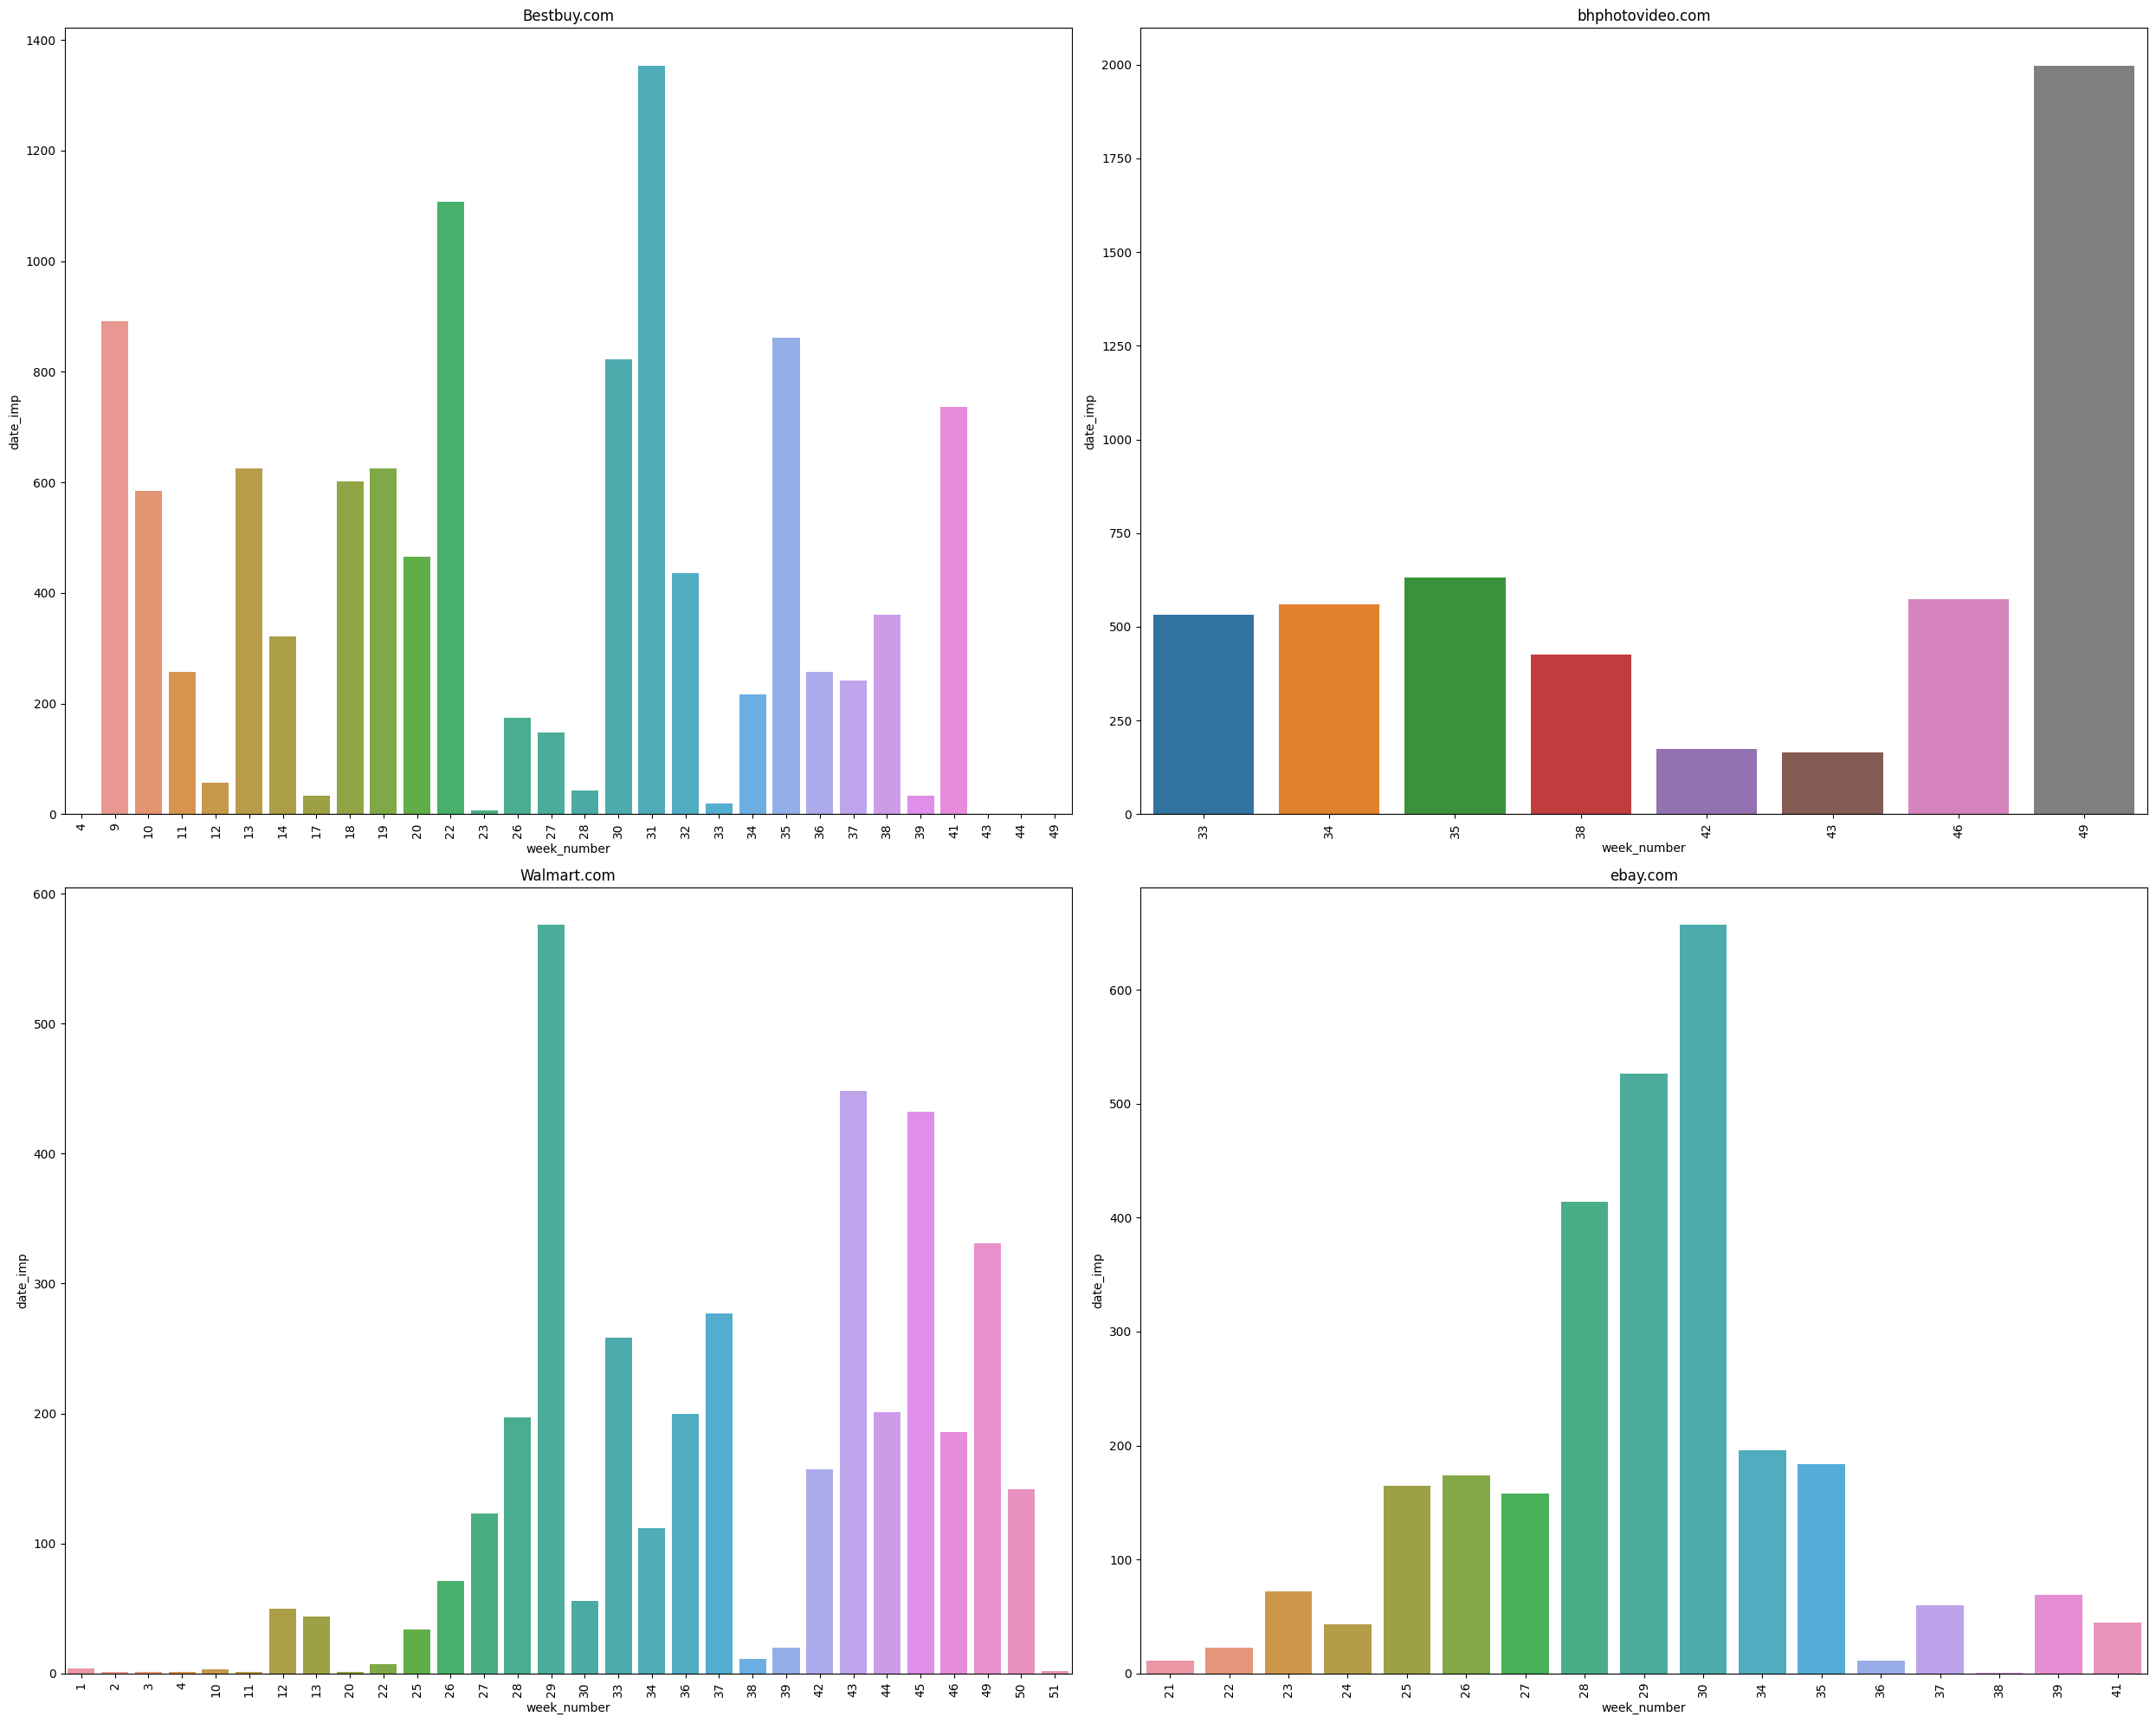

In [26]:
plt.figure(figsize=(25, 20))
plt.subplot(2,2,1)
aux3 = df_best[['date_imp', 'week_number']].groupby('week_number').count().sort_values(by='date_imp', ascending=False).reset_index()
#plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
plt.title("Bestbuy.com")
sns.barplot(data=aux3, x="week_number", y="date_imp");



plt.subplot(2,2,2)
aux4 = df_bh[['date_imp', 'week_number']].groupby('week_number').count().sort_values(by='date_imp', ascending=False).reset_index()
#plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
plt.title("bhphotovideo.com")
sns.barplot(data=aux4, x="week_number", y="date_imp");



plt.subplot(2,2,3)
aux5 = df_walmart[['date_imp', 'week_number']].groupby('week_number').count().sort_values(by='date_imp', ascending=False).reset_index()
#plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
plt.title("Walmart.com")
sns.barplot(data=aux5, x="week_number", y="date_imp");



plt.subplot(2,2,4)
aux6 = df_ebay[['date_imp', 'week_number']].groupby('week_number').count().sort_values(by='date_imp', ascending=False).reset_index()
#plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
plt.title("ebay.com")
sns.barplot(data=aux6, x="week_number", y="date_imp");

plt.tight_layout()

## 2.6 Meses que mais vendem

### 2.6.1 Meses que mais vendem no geral

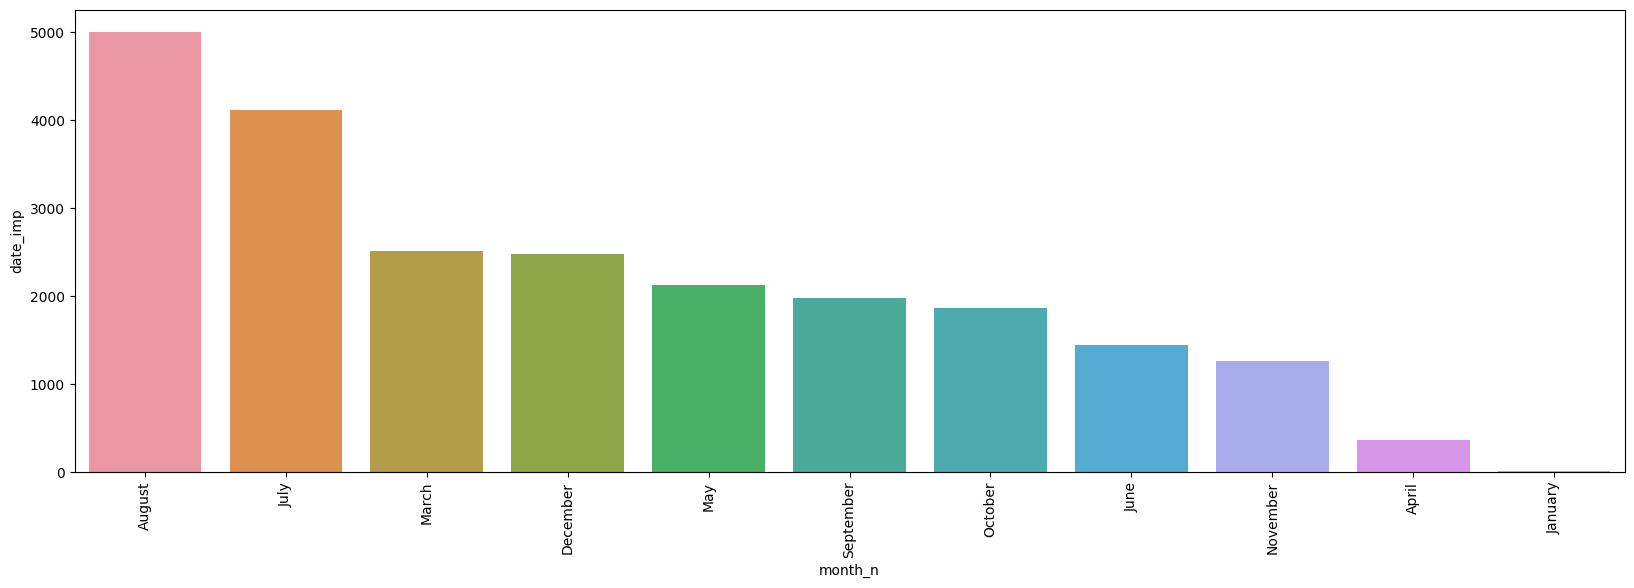

In [27]:
aux2 = df2[['date_imp', 'month_n']].groupby('month_n').count().sort_values(by='date_imp', ascending=False).reset_index()
plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
sns.barplot(data=aux2, x="month_n", y="date_imp");

### 2.6.2 Meses que mais vendem por loja

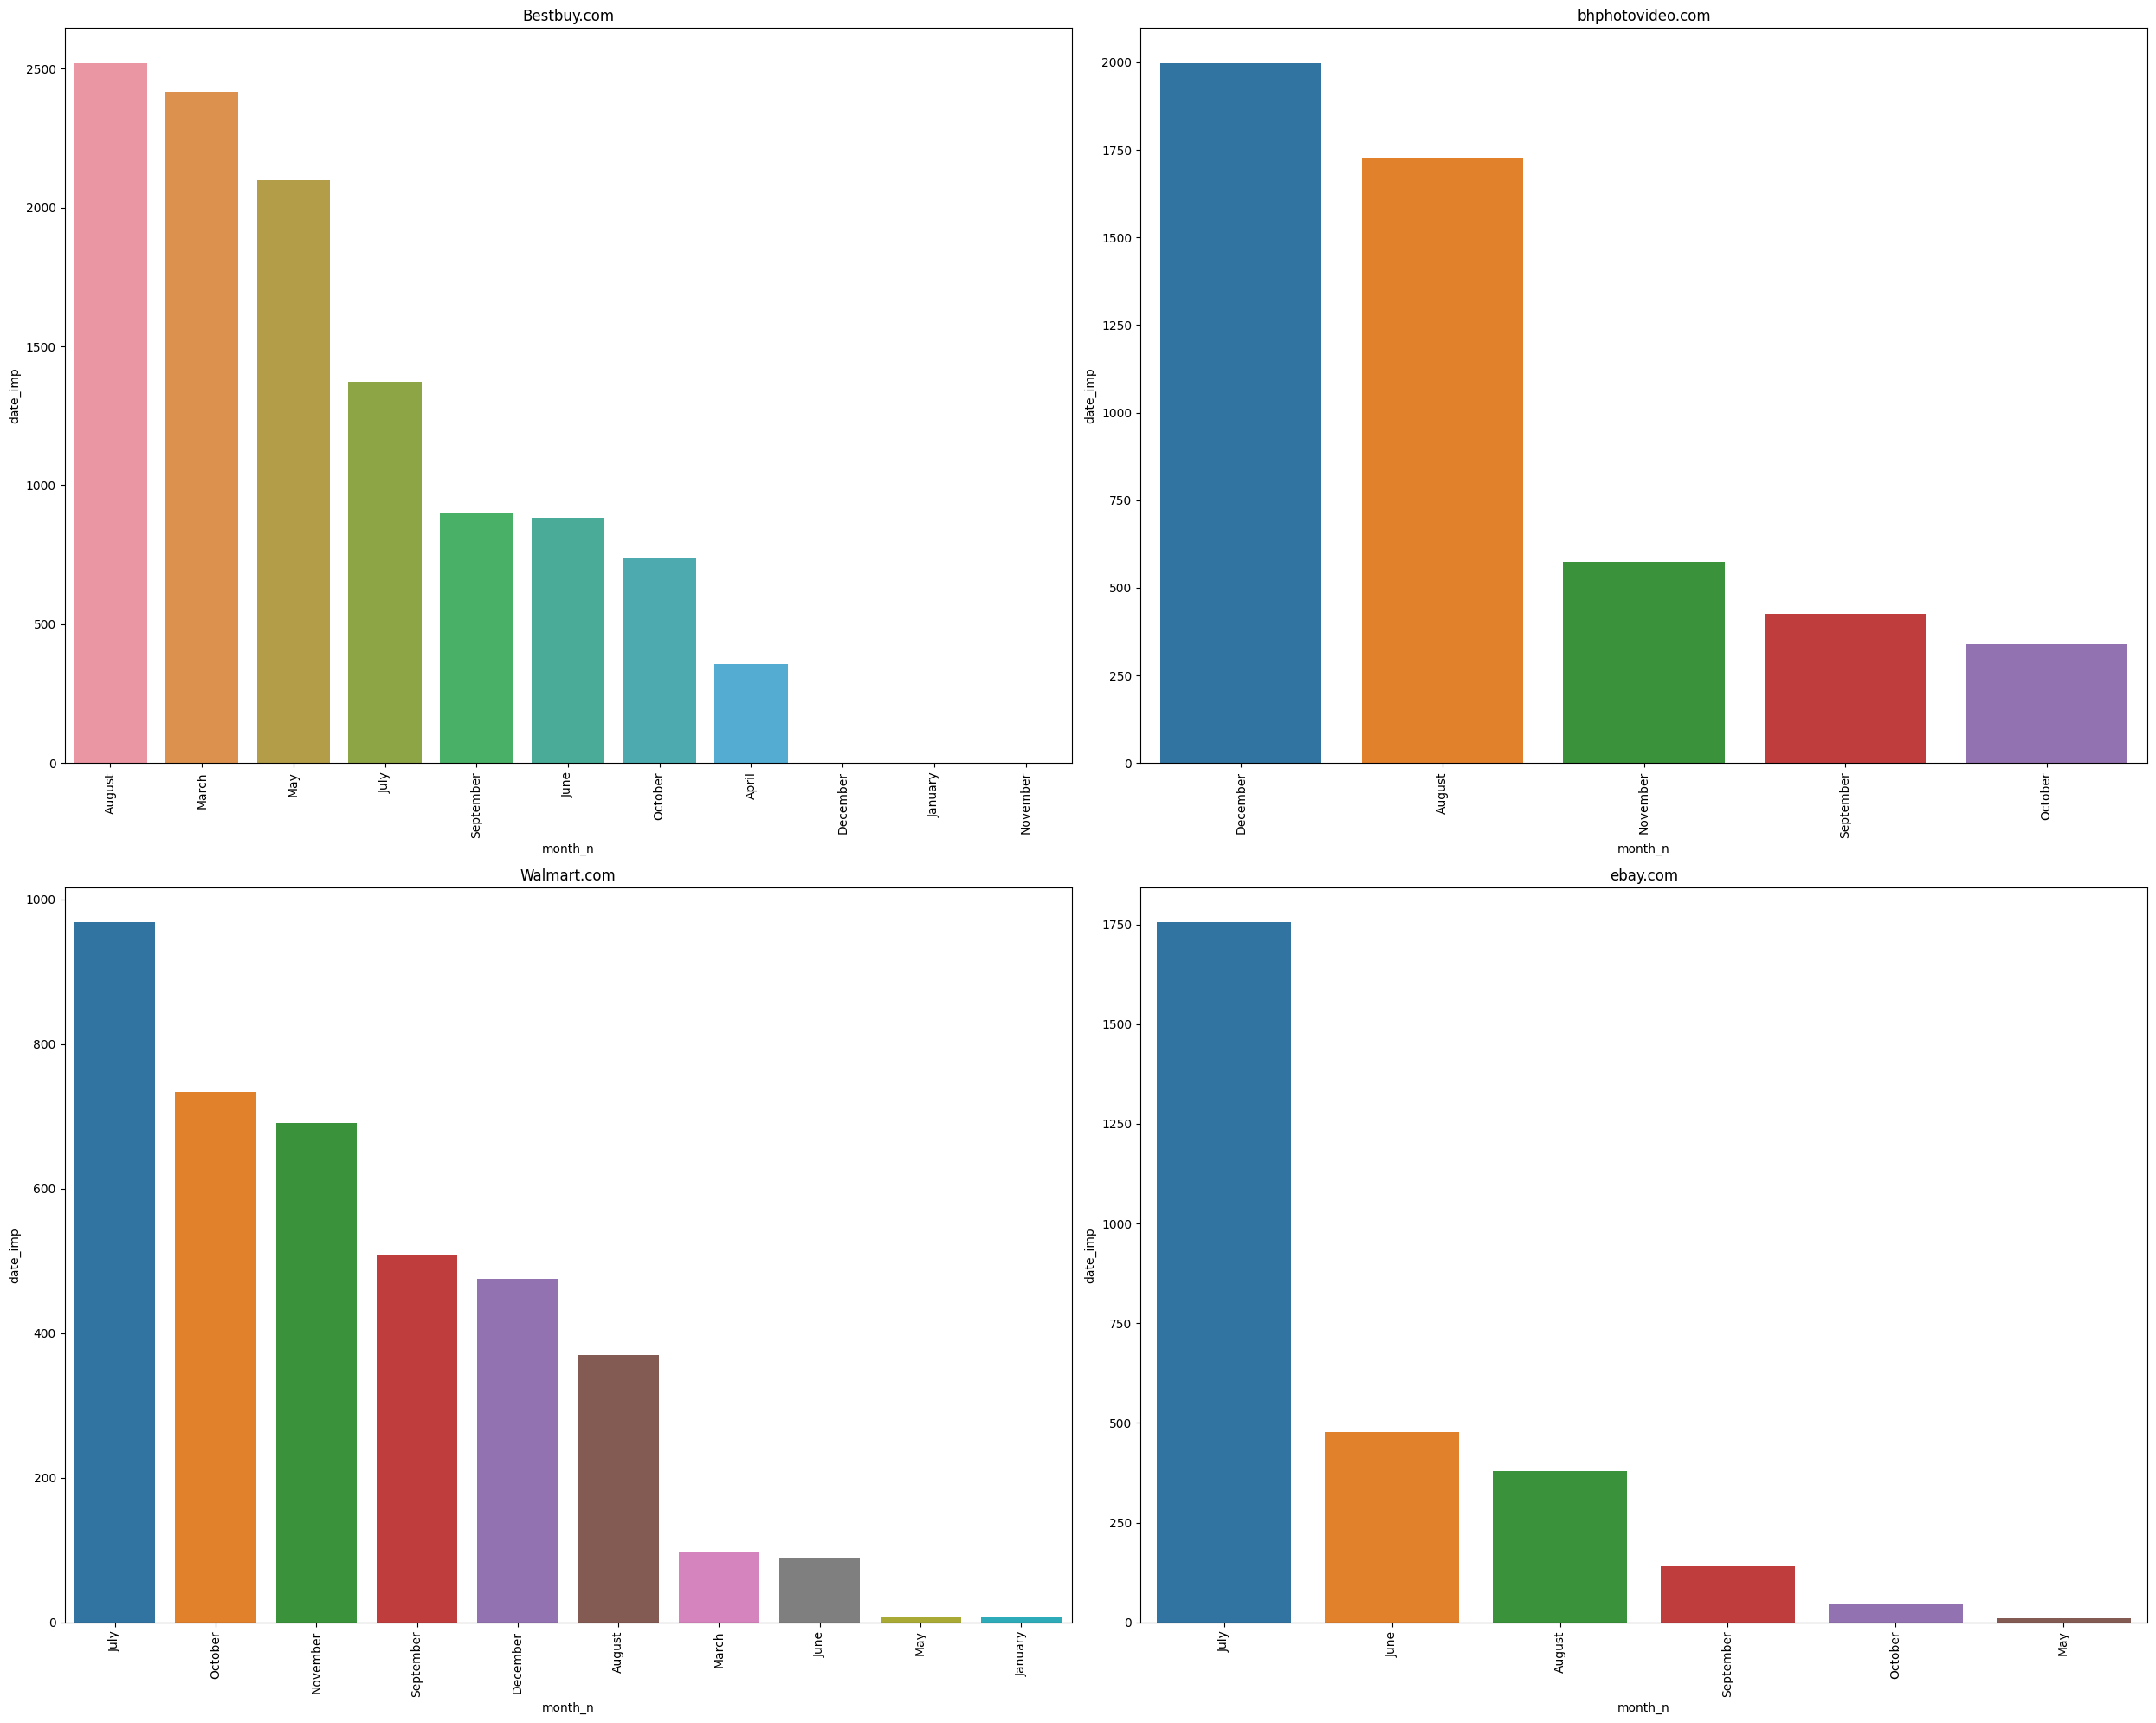

In [28]:
plt.figure(figsize=(25, 20))
plt.subplot(2,2,1)
aux3 = df_best[['date_imp', 'month_n']].groupby('month_n').count().sort_values(by='date_imp', ascending=False).reset_index()
#plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
plt.title("Bestbuy.com")
sns.barplot(data=aux3, x="month_n", y="date_imp");



plt.subplot(2,2,2)
aux4 = df_bh[['date_imp', 'month_n']].groupby('month_n').count().sort_values(by='date_imp', ascending=False).reset_index()
#plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
plt.title("bhphotovideo.com")
sns.barplot(data=aux4, x="month_n", y="date_imp");



plt.subplot(2,2,3)
aux5 = df_walmart[['date_imp', 'month_n']].groupby('month_n').count().sort_values(by='date_imp', ascending=False).reset_index()
#plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
plt.title("Walmart.com")
sns.barplot(data=aux5, x="month_n", y="date_imp");



plt.subplot(2,2,4)
aux6 = df_ebay[['date_imp', 'month_n']].groupby('month_n').count().sort_values(by='date_imp', ascending=False).reset_index()
#plt.figure(figsize=(20, 6))
plt.xticks(rotation =90)
plt.title("ebay.com")
sns.barplot(data=aux6, x="month_n", y="date_imp");

plt.tight_layout()

# 3.0 Feature Engineering

In [29]:
df3 = df2.copy()

## 3.1 categoria mais vendida

### 3.1.1 laptop, computer

In [30]:
#seleção da categoria que realizou mais vendas
df_laptop = df_best[df_best['category_name']=='laptop, computer']

In [31]:
#checando os NAs
df_laptop.isna().sum()

date_imp             0
category_name        0
name                 0
price                0
disc_price           0
merchant             0
disc_percentage      0
is_sale              0
imp_count            0
brand                0
p_description        0
date_added           0
date_seen            0
date_updated         0
manufacturer       627
day_n                0
month                0
month_n              0
day                  0
week_number          0
dtype: int64

In [32]:
#vendas por semana
test = df_laptop.groupby(['name', 'week_number']).agg({'disc_price': 'mean' ,'date_imp': 'count' }).reset_index()
test

,name,week_number,disc_price,date_imp
0,"12 MacBook (Mid 2017, Gold)",30,1599.99,1
1,"12 MacBook (Mid 2017, Gold)",31,1551.99,8
2,"12 MacBook (Mid 2017, Gold)",33,1454.99,2
3,"12 MacBook (Mid 2017, Gold)",34,1551.99,2
4,"12 MacBook (Mid 2017, Gold)",35,1474.49,4
...,...,...,...,...
454,Samsung - Notebook 5 15.6 Touch-Screen Laptop ...,31,610.99,4
455,Samsung - Notebook 5 15.6 Touch-Screen Laptop ...,34,600.99,2
456,Samsung - Notebook 5 15.6 Touch-Screen Laptop ...,35,600.99,2
457,Samsung - Notebook 5 15.6 Touch-Screen Laptop ...,38,591.49,2


In [33]:
#criando x_values_laptop
x_pivot_laptop = test.pivot(index='week_number', columns='name' ,values='disc_price')
x_values_laptop = pd.DataFrame(x_pivot_laptop.to_records())
x_values_laptop

,week_number,"12 MacBook (Mid 2017, Gold)","12 MacBook (Mid 2017, Silver)",12.3 32GB Multi-Touch 2-in-1 Chromebook Plus,"13.3 MacBook Air (Mid 2017, Silver)","15.4 MacBook Pro with Touch Bar (Late 2016, Silver)","15.4 MacBook Pro with Touch Bar (Late 2016, Space Gray)",ASUS VivoBook Max X541SA 15.6Inch Laptop Intel Pentium 4GB Memory 500GB HD Matte IMR X541SA-PD0703X,"Acer - 2-in-1 15.6 Refurbished Touch-Screen Laptop - Intel Core i7 - 12GB Memory - NVIDIA GeForce 940MX - 1TB Hard Drive - Steel gray""",Acer 15.6 Chromebook CB5-571-C4G4,...,"HP - ProBook 14 Laptop - Intel Core i5 - 4GB Memory - 500GB Hard Drive - Black""","HP 15-AY103DX 15.6 Touchscreen Touch Screen HD Laptop Notebook PC Computer 7th Gen i5-7200U Kaby Lake 8GB Memory 1TB HDD Hard Drive Windows 10""","Lenovo - 100S-14IBR 14 Laptop - Intel Celeron - 2GB Memory - 32GB eMMC Flash Memory - Navy blue""","Lenovo - Yoga 710 2-in-1 11.6 Touch-Screen Laptop - Intel Core i5 - 8GB Memory - 128GB Solid State Drive - Silver Tablet PC Notebook 80V6000PUS""","Lenovo 80TX0007US Y 710-11ISK 11.6-Inch FHD Touch Laptop (Pentium 4405Y, 4 GB Ram, 128 GB SSD, Windows 10), SilverNotebook PC Computer Tablet Touchscreen Screen 2-in-1","Lenovo Flex 4 1470 80SA0000US 2-in-1 - 14 HD Touch - Pentium 4405U 2.1Ghz - 4GB - 500GB""","MSI - WS Series 15.6 Laptop - Intel Core i7 - 16GB Memory - 256GB Solid State Drive + 2TB Hard Drive - Aluminum Black""","New Asus Q524u 15.6fhd 2in1 Touch I77500u 3.5ghz 16gb Ddr4 2tb Hd 940mx2gb W10""","Razer - Blade Pro 17.3 4K Ultra HD Touch-Screen Laptop - Intel Core i7 - 32GB Memory - NVIDIA GeForce GTX 1080 - 1TB SSD - Black""","Samsung - Notebook 5 15.6 Touch-Screen Laptop - Intel Core i5 - 8GB Memory - NVIDIA GeForce 920MX - 1TB Hard Drive - Solid black"""
0,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9,NaN,NaN,426.495,NaN,2799.99,2599.99,NaN,899.99,236.495,...,799.99,499.99,NaN,664.99,379.99,316.99,NaN,807.49,NaN,617.49
2,10,NaN,NaN,426.495,NaN,2799.99,2599.99,NaN,899.99,238.995,...,819.99,429.99,229.99,664.99,474.99,335.99,NaN,949.99,NaN,617.49
3,11,NaN,NaN,NaN,NaN,2715.99,2482.99,NaN,NaN,NaN,...,819.99,NaN,218.49,NaN,474.99,383.99,NaN,NaN,NaN,569.99
4,13,NaN,NaN,449.000,NaN,2547.99,2353.99,NaN,849.99,223.995,...,819.99,499.99,203.49,636.99,444.99,369.99,2399.99,909.99,NaN,591.49
5,14,NaN,NaN,408.495,NaN,2365.99,2172.99,NaN,899.99,223.995,...,NaN,449.99,176.99,591.49,NaN,323.49,NaN,773.49,NaN,NaN
6,18,NaN,NaN,426.495,NaN,2570.49,2302.99,NaN,809.99,249.000,...,819.99,499.99,218.49,664.99,415.99,337.49,2399.99,949.99,4399.99,569.99
7,19,NaN,NaN,399.995,NaN,2715.99,2469.99,NaN,809.99,249.000,...,819.99,427.49,170.99,601.49,369.99,328.99,2399.99,924.99,4179.99,610.99
8,20,NaN,NaN,426.495,NaN,2715.99,2469.99,NaN,809.99,249.000,...,NaN,469.99,170.99,664.99,314.99,NaN,NaN,785.99,NaN,NaN
9,22,NaN,NaN,413.990,NaN,2618.99,2374.99,NaN,764.99,249.000,...,819.99,469.99,170.99,569.99,NaN,332.49,2399.99,924.99,4179.99,610.99


In [34]:
#criando y_values_laptop
y_pivot_laptop = test.pivot(index='week_number', columns='name', values='date_imp')
y_values_laptop = pd.DataFrame(y_pivot_laptop.to_records())
y_values_laptop

,week_number,"12 MacBook (Mid 2017, Gold)","12 MacBook (Mid 2017, Silver)",12.3 32GB Multi-Touch 2-in-1 Chromebook Plus,"13.3 MacBook Air (Mid 2017, Silver)","15.4 MacBook Pro with Touch Bar (Late 2016, Silver)","15.4 MacBook Pro with Touch Bar (Late 2016, Space Gray)",ASUS VivoBook Max X541SA 15.6Inch Laptop Intel Pentium 4GB Memory 500GB HD Matte IMR X541SA-PD0703X,"Acer - 2-in-1 15.6 Refurbished Touch-Screen Laptop - Intel Core i7 - 12GB Memory - NVIDIA GeForce 940MX - 1TB Hard Drive - Steel gray""",Acer 15.6 Chromebook CB5-571-C4G4,...,"HP - ProBook 14 Laptop - Intel Core i5 - 4GB Memory - 500GB Hard Drive - Black""","HP 15-AY103DX 15.6 Touchscreen Touch Screen HD Laptop Notebook PC Computer 7th Gen i5-7200U Kaby Lake 8GB Memory 1TB HDD Hard Drive Windows 10""","Lenovo - 100S-14IBR 14 Laptop - Intel Celeron - 2GB Memory - 32GB eMMC Flash Memory - Navy blue""","Lenovo - Yoga 710 2-in-1 11.6 Touch-Screen Laptop - Intel Core i5 - 8GB Memory - 128GB Solid State Drive - Silver Tablet PC Notebook 80V6000PUS""","Lenovo 80TX0007US Y 710-11ISK 11.6-Inch FHD Touch Laptop (Pentium 4405Y, 4 GB Ram, 128 GB SSD, Windows 10), SilverNotebook PC Computer Tablet Touchscreen Screen 2-in-1","Lenovo Flex 4 1470 80SA0000US 2-in-1 - 14 HD Touch - Pentium 4405U 2.1Ghz - 4GB - 500GB""","MSI - WS Series 15.6 Laptop - Intel Core i7 - 16GB Memory - 256GB Solid State Drive + 2TB Hard Drive - Aluminum Black""","New Asus Q524u 15.6fhd 2in1 Touch I77500u 3.5ghz 16gb Ddr4 2tb Hd 940mx2gb W10""","Razer - Blade Pro 17.3 4K Ultra HD Touch-Screen Laptop - Intel Core i7 - 32GB Memory - NVIDIA GeForce GTX 1080 - 1TB SSD - Black""","Samsung - Notebook 5 15.6 Touch-Screen Laptop - Intel Core i5 - 8GB Memory - NVIDIA GeForce 920MX - 1TB Hard Drive - Solid black"""
0,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9,NaN,NaN,4.0,NaN,3.0,6.0,NaN,2.0,4.0,...,1.0,2.0,NaN,4.0,4.0,4.0,NaN,4.0,NaN,2.0
2,10,NaN,NaN,2.0,NaN,1.0,4.0,NaN,1.0,2.0,...,1.0,1.0,1.0,2.0,2.0,2.0,NaN,2.0,NaN,2.0
3,11,NaN,NaN,NaN,NaN,2.0,4.0,NaN,NaN,NaN,...,1.0,NaN,2.0,NaN,2.0,2.0,NaN,NaN,NaN,2.0
4,13,NaN,NaN,1.0,NaN,2.0,8.0,NaN,1.0,2.0,...,1.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,NaN,2.0
5,14,NaN,NaN,2.0,NaN,2.0,4.0,NaN,1.0,2.0,...,NaN,1.0,2.0,2.0,NaN,2.0,NaN,2.0,NaN,NaN
6,18,NaN,NaN,2.0,NaN,2.0,8.0,NaN,1.0,1.0,...,1.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0
7,19,NaN,NaN,2.0,NaN,4.0,8.0,NaN,1.0,1.0,...,1.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0
8,20,NaN,NaN,2.0,NaN,2.0,4.0,NaN,1.0,1.0,...,NaN,2.0,2.0,2.0,2.0,NaN,NaN,2.0,NaN,NaN
9,22,NaN,NaN,2.0,NaN,6.0,12.0,NaN,2.0,1.0,...,2.0,4.0,2.0,2.0,NaN,4.0,2.0,4.0,4.0,4.0


# Descrição dos novos Dataframes

# 4.0 Descrição dos dados

## 4.1 Data Dimension

In [35]:
print(f'Number of rows: {x_values_laptop.shape[0]}')
print(f'Number of columns: {x_values_laptop.shape[1]}')

Number of rows: 26
Number of columns: 40


In [36]:
print(f'Number of rows: {y_values_laptop.shape[0]}')
print(f'Number of columns: {y_values_laptop.shape[1]}')

Number of rows: 26
Number of columns: 40


## 4.2 Data Types

In [37]:
x_values_laptop.dtypes

week_number                                                                                                                                                                                              int64
12 MacBook (Mid 2017, Gold)                                                                                                                                                                            float64
12 MacBook (Mid 2017, Silver)                                                                                                                                                                          float64
12.3 32GB Multi-Touch 2-in-1 Chromebook Plus                                                                                                                                                           float64
13.3 MacBook Air (Mid 2017, Silver)                                                                                                                                         

In [38]:
y_values_laptop.dtypes

week_number                                                                                                                                                                                              int64
12 MacBook (Mid 2017, Gold)                                                                                                                                                                            float64
12 MacBook (Mid 2017, Silver)                                                                                                                                                                          float64
12.3 32GB Multi-Touch 2-in-1 Chromebook Plus                                                                                                                                                           float64
13.3 MacBook Air (Mid 2017, Silver)                                                                                                                                         

## 4.3 Check NA

In [39]:
x_values_laptop.isna().sum()

week_number                                                                                                                                                                                             0
12 MacBook (Mid 2017, Gold)                                                                                                                                                                            17
12 MacBook (Mid 2017, Silver)                                                                                                                                                                          18
12.3 32GB Multi-Touch 2-in-1 Chromebook Plus                                                                                                                                                           13
13.3 MacBook Air (Mid 2017, Silver)                                                                                                                                                             

In [40]:
y_values_laptop.isna().sum()

week_number                                                                                                                                                                                             0
12 MacBook (Mid 2017, Gold)                                                                                                                                                                            17
12 MacBook (Mid 2017, Silver)                                                                                                                                                                          18
12.3 32GB Multi-Touch 2-in-1 Chromebook Plus                                                                                                                                                           13
13.3 MacBook Air (Mid 2017, Silver)                                                                                                                                                             

## 4.4 Replace NA

In [41]:
a = np.round(x_values_laptop.median(), 2)
x_values_laptop.fillna(a, inplace=True)
x_values_laptop

,week_number,"12 MacBook (Mid 2017, Gold)","12 MacBook (Mid 2017, Silver)",12.3 32GB Multi-Touch 2-in-1 Chromebook Plus,"13.3 MacBook Air (Mid 2017, Silver)","15.4 MacBook Pro with Touch Bar (Late 2016, Silver)","15.4 MacBook Pro with Touch Bar (Late 2016, Space Gray)",ASUS VivoBook Max X541SA 15.6Inch Laptop Intel Pentium 4GB Memory 500GB HD Matte IMR X541SA-PD0703X,"Acer - 2-in-1 15.6 Refurbished Touch-Screen Laptop - Intel Core i7 - 12GB Memory - NVIDIA GeForce 940MX - 1TB Hard Drive - Steel gray""",Acer 15.6 Chromebook CB5-571-C4G4,...,"HP - ProBook 14 Laptop - Intel Core i5 - 4GB Memory - 500GB Hard Drive - Black""","HP 15-AY103DX 15.6 Touchscreen Touch Screen HD Laptop Notebook PC Computer 7th Gen i5-7200U Kaby Lake 8GB Memory 1TB HDD Hard Drive Windows 10""","Lenovo - 100S-14IBR 14 Laptop - Intel Celeron - 2GB Memory - 32GB eMMC Flash Memory - Navy blue""","Lenovo - Yoga 710 2-in-1 11.6 Touch-Screen Laptop - Intel Core i5 - 8GB Memory - 128GB Solid State Drive - Silver Tablet PC Notebook 80V6000PUS""","Lenovo 80TX0007US Y 710-11ISK 11.6-Inch FHD Touch Laptop (Pentium 4405Y, 4 GB Ram, 128 GB SSD, Windows 10), SilverNotebook PC Computer Tablet Touchscreen Screen 2-in-1","Lenovo Flex 4 1470 80SA0000US 2-in-1 - 14 HD Touch - Pentium 4405U 2.1Ghz - 4GB - 500GB""","MSI - WS Series 15.6 Laptop - Intel Core i7 - 16GB Memory - 256GB Solid State Drive + 2TB Hard Drive - Aluminum Black""","New Asus Q524u 15.6fhd 2in1 Touch I77500u 3.5ghz 16gb Ddr4 2tb Hd 940mx2gb W10""","Razer - Blade Pro 17.3 4K Ultra HD Touch-Screen Laptop - Intel Core i7 - 32GB Memory - NVIDIA GeForce GTX 1080 - 1TB SSD - Black""","Samsung - Notebook 5 15.6 Touch-Screen Laptop - Intel Core i5 - 8GB Memory - NVIDIA GeForce 920MX - 1TB Hard Drive - Solid black"""
0,4,1551.99,1299.99,415.500,949.99,2618.99,2353.99,304.99,829.99,249.000,...,819.99,463.74,218.49,601.49,415.99,337.49,2399.99,853.74,4179.99,610.99
1,9,1551.99,1299.99,426.495,949.99,2799.99,2599.99,304.99,899.99,236.495,...,799.99,499.99,218.49,664.99,379.99,316.99,2399.99,807.49,4179.99,617.49
2,10,1551.99,1299.99,426.495,949.99,2799.99,2599.99,304.99,899.99,238.995,...,819.99,429.99,229.99,664.99,474.99,335.99,2399.99,949.99,4179.99,617.49
3,11,1551.99,1299.99,415.500,949.99,2715.99,2482.99,304.99,829.99,249.000,...,819.99,463.74,218.49,601.49,474.99,383.99,2399.99,853.74,4179.99,569.99
4,13,1551.99,1299.99,449.000,949.99,2547.99,2353.99,304.99,849.99,223.995,...,819.99,499.99,203.49,636.99,444.99,369.99,2399.99,909.99,4179.99,591.49
5,14,1551.99,1299.99,408.495,949.99,2365.99,2172.99,304.99,899.99,223.995,...,819.99,449.99,176.99,591.49,415.99,323.49,2399.99,773.49,4179.99,610.99
6,18,1551.99,1299.99,426.495,949.99,2570.49,2302.99,304.99,809.99,249.000,...,819.99,499.99,218.49,664.99,415.99,337.49,2399.99,949.99,4399.99,569.99
7,19,1551.99,1299.99,399.995,949.99,2715.99,2469.99,304.99,809.99,249.000,...,819.99,427.49,170.99,601.49,369.99,328.99,2399.99,924.99,4179.99,610.99
8,20,1551.99,1299.99,426.495,949.99,2715.99,2469.99,304.99,809.99,249.000,...,819.99,469.99,170.99,664.99,314.99,337.49,2399.99,785.99,4179.99,610.99
9,22,1551.99,1299.99,413.990,949.99,2618.99,2374.99,304.99,764.99,249.000,...,819.99,469.99,170.99,569.99,415.99,332.49,2399.99,924.99,4179.99,610.99


In [42]:
#b = np.round(x_values_laptop.median(), 2)
y_values_laptop.fillna(0, inplace=True)
y_values_laptop

,week_number,"12 MacBook (Mid 2017, Gold)","12 MacBook (Mid 2017, Silver)",12.3 32GB Multi-Touch 2-in-1 Chromebook Plus,"13.3 MacBook Air (Mid 2017, Silver)","15.4 MacBook Pro with Touch Bar (Late 2016, Silver)","15.4 MacBook Pro with Touch Bar (Late 2016, Space Gray)",ASUS VivoBook Max X541SA 15.6Inch Laptop Intel Pentium 4GB Memory 500GB HD Matte IMR X541SA-PD0703X,"Acer - 2-in-1 15.6 Refurbished Touch-Screen Laptop - Intel Core i7 - 12GB Memory - NVIDIA GeForce 940MX - 1TB Hard Drive - Steel gray""",Acer 15.6 Chromebook CB5-571-C4G4,...,"HP - ProBook 14 Laptop - Intel Core i5 - 4GB Memory - 500GB Hard Drive - Black""","HP 15-AY103DX 15.6 Touchscreen Touch Screen HD Laptop Notebook PC Computer 7th Gen i5-7200U Kaby Lake 8GB Memory 1TB HDD Hard Drive Windows 10""","Lenovo - 100S-14IBR 14 Laptop - Intel Celeron - 2GB Memory - 32GB eMMC Flash Memory - Navy blue""","Lenovo - Yoga 710 2-in-1 11.6 Touch-Screen Laptop - Intel Core i5 - 8GB Memory - 128GB Solid State Drive - Silver Tablet PC Notebook 80V6000PUS""","Lenovo 80TX0007US Y 710-11ISK 11.6-Inch FHD Touch Laptop (Pentium 4405Y, 4 GB Ram, 128 GB SSD, Windows 10), SilverNotebook PC Computer Tablet Touchscreen Screen 2-in-1","Lenovo Flex 4 1470 80SA0000US 2-in-1 - 14 HD Touch - Pentium 4405U 2.1Ghz - 4GB - 500GB""","MSI - WS Series 15.6 Laptop - Intel Core i7 - 16GB Memory - 256GB Solid State Drive + 2TB Hard Drive - Aluminum Black""","New Asus Q524u 15.6fhd 2in1 Touch I77500u 3.5ghz 16gb Ddr4 2tb Hd 940mx2gb W10""","Razer - Blade Pro 17.3 4K Ultra HD Touch-Screen Laptop - Intel Core i7 - 32GB Memory - NVIDIA GeForce GTX 1080 - 1TB SSD - Black""","Samsung - Notebook 5 15.6 Touch-Screen Laptop - Intel Core i5 - 8GB Memory - NVIDIA GeForce 920MX - 1TB Hard Drive - Solid black"""
0,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,9,0.0,0.0,4.0,0.0,3.0,6.0,0.0,2.0,4.0,...,1.0,2.0,0.0,4.0,4.0,4.0,0.0,4.0,0.0,2.0
2,10,0.0,0.0,2.0,0.0,1.0,4.0,0.0,1.0,2.0,...,1.0,1.0,1.0,2.0,2.0,2.0,0.0,2.0,0.0,2.0
3,11,0.0,0.0,0.0,0.0,2.0,4.0,0.0,0.0,0.0,...,1.0,0.0,2.0,0.0,2.0,2.0,0.0,0.0,0.0,2.0
4,13,0.0,0.0,1.0,0.0,2.0,8.0,0.0,1.0,2.0,...,1.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,0.0,2.0
5,14,0.0,0.0,2.0,0.0,2.0,4.0,0.0,1.0,2.0,...,0.0,1.0,2.0,2.0,0.0,2.0,0.0,2.0,0.0,0.0
6,18,0.0,0.0,2.0,0.0,2.0,8.0,0.0,1.0,1.0,...,1.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0
7,19,0.0,0.0,2.0,0.0,4.0,8.0,0.0,1.0,1.0,...,1.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0
8,20,0.0,0.0,2.0,0.0,2.0,4.0,0.0,1.0,1.0,...,0.0,2.0,2.0,2.0,2.0,0.0,0.0,2.0,0.0,0.0
9,22,0.0,0.0,2.0,0.0,6.0,12.0,0.0,2.0,1.0,...,2.0,4.0,2.0,2.0,0.0,4.0,2.0,4.0,4.0,4.0


## 4.5 Descriptive Statistics

### 4.5.1 Numerical Attributes

In [43]:
num_attributes_x = x_values_laptop.select_dtypes( include = ['int64', 'float64'])
num_attributes_y = y_values_laptop.select_dtypes( include = ['int64', 'float64'])

#### 4.5.1.1 x_values_laptop

In [44]:
np.round(x_values_laptop.median(), 2)

# Central tendency - mean, median
ct1_x = pd.DataFrame( np.round(num_attributes_x.apply( np.mean ), 2)).T
ct2_x = pd.DataFrame( num_attributes_x.apply( np.median )).T

# dispersion - std, min, max, range, skew, kurtosis
d1_x = pd.DataFrame( np.round(num_attributes_x.apply( np.std ), 2)).T
d2_x = pd.DataFrame( np.round(num_attributes_x.apply( min ), 2)).T
d3_x = pd.DataFrame( num_attributes_x.apply( max )).T
d4_x = pd.DataFrame( np.round(num_attributes_x.apply( lambda x: x.max() - x.min() ), 2)).T
d5_x = pd.DataFrame( num_attributes_x.apply( lambda x: x.skew() )).T
d6_x = pd.DataFrame( num_attributes_x.apply( lambda x: x.kurtosis() )).T

#concat
m_x = pd.concat( [d2_x, d3_x, d4_x, ct1_x, ct2_x, d1_x, d5_x, d6_x] ).T.reset_index()
m_x.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis'] 
m_x

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,week_number,4.00,49.00,45.00,27.08,29.00,11.95,-0.186167,-0.905369
1,"12 MacBook (Mid 2017, Gold)",1454.99,1599.99,145.00,1547.12,1551.99,25.65,-2.457686,8.310054
2,"12 MacBook (Mid 2017, Silver)",1234.99,1299.99,65.00,1295.99,1299.99,14.32,-3.735032,13.784949
3,12.3 32GB Multi-Touch 2-in-1 Chromebook Plus,373.00,449.00,76.00,413.19,415.50,15.42,-1.054924,2.830858
4,"13.3 MacBook Air (Mid 2017, Silver)",911.99,969.99,58.00,949.30,949.99,8.39,-2.975611,16.702015
5,"15.4 MacBook Pro with Touch Bar (Late 2016, Si...",2327.99,2799.99,472.00,2607.39,2618.99,112.83,-1.131897,2.049122
6,"15.4 MacBook Pro with Touch Bar (Late 2016, Sp...",2023.99,2599.99,576.00,2346.91,2353.99,122.52,-0.274833,1.347179
7,ASUS VivoBook Max X541SA 15.6Inch Laptop Intel...,237.49,313.49,76.00,299.72,304.99,16.35,-2.916993,8.218479
8,Acer - 2-in-1 15.6 Refurbished Touch-Screen La...,764.99,899.99,135.00,834.03,829.99,27.80,0.937281,2.943939
9,Acer 15.6 Chromebook CB5-571-C4G4,199.99,249.00,49.01,242.48,249.00,14.02,-2.306458,4.514429


#### 4.5.1.2 y_values_laptop

In [45]:
# Central tendency - mean, median
ct1_y = pd.DataFrame( np.round(num_attributes_y.apply( np.mean ), 2)).T
ct2_y = pd.DataFrame( num_attributes_y.apply( np.median )).T

# dispersion - std, min, max, range, skew, kurtosis
d1_y = pd.DataFrame( np.round(num_attributes_y.apply( np.std ), 2)).T
d2_y = pd.DataFrame( num_attributes_y.apply( min )).T
d3_y = pd.DataFrame( num_attributes_y.apply( max )).T
d4_y = pd.DataFrame( num_attributes_y.apply( lambda x: x.max() - x.min() )).T
d5_y = pd.DataFrame( num_attributes_y.apply( lambda x: x.skew() )).T
d6_y = pd.DataFrame( num_attributes_y.apply( lambda x: x.kurtosis() )).T

#concat
m_y = pd.concat( [d2_y, d3_y, d4_y, ct1_y, ct2_y, d1_y, d5_y, d6_y] ).T.reset_index()
m_y.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis'] 
m_y

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,week_number,4.0,49.0,45.0,27.08,29.0,11.95,-0.186167,-0.905369
1,"12 MacBook (Mid 2017, Gold)",0.0,8.0,8.0,0.96,0.0,1.76,2.738840,9.024976
2,"12 MacBook (Mid 2017, Silver)",0.0,2.0,2.0,0.38,0.0,0.62,1.474017,1.189701
3,12.3 32GB Multi-Touch 2-in-1 Chromebook Plus,0.0,4.0,4.0,1.04,0.5,1.13,0.606680,-0.428079
4,"13.3 MacBook Air (Mid 2017, Silver)",0.0,2.0,2.0,0.38,0.0,0.79,1.658711,0.807453
5,"15.4 MacBook Pro with Touch Bar (Late 2016, Si...",0.0,6.0,6.0,1.15,0.0,1.61,1.437577,1.673167
6,"15.4 MacBook Pro with Touch Bar (Late 2016, Sp...",0.0,12.0,12.0,3.23,1.0,3.89,0.951022,-0.225438
7,ASUS VivoBook Max X541SA 15.6Inch Laptop Intel...,0.0,2.0,2.0,0.54,0.0,0.89,1.105353,-0.849951
8,Acer - 2-in-1 15.6 Refurbished Touch-Screen La...,0.0,2.0,2.0,0.38,0.0,0.62,1.474017,1.189701
9,Acer 15.6 Chromebook CB5-571-C4G4,0.0,4.0,4.0,0.77,1.0,0.93,1.711207,4.066693


# 5.0 Análise Exploratória dos Dados

In [46]:
df_x = x_values_laptop.copy()
df_y = y_values_laptop.copy()

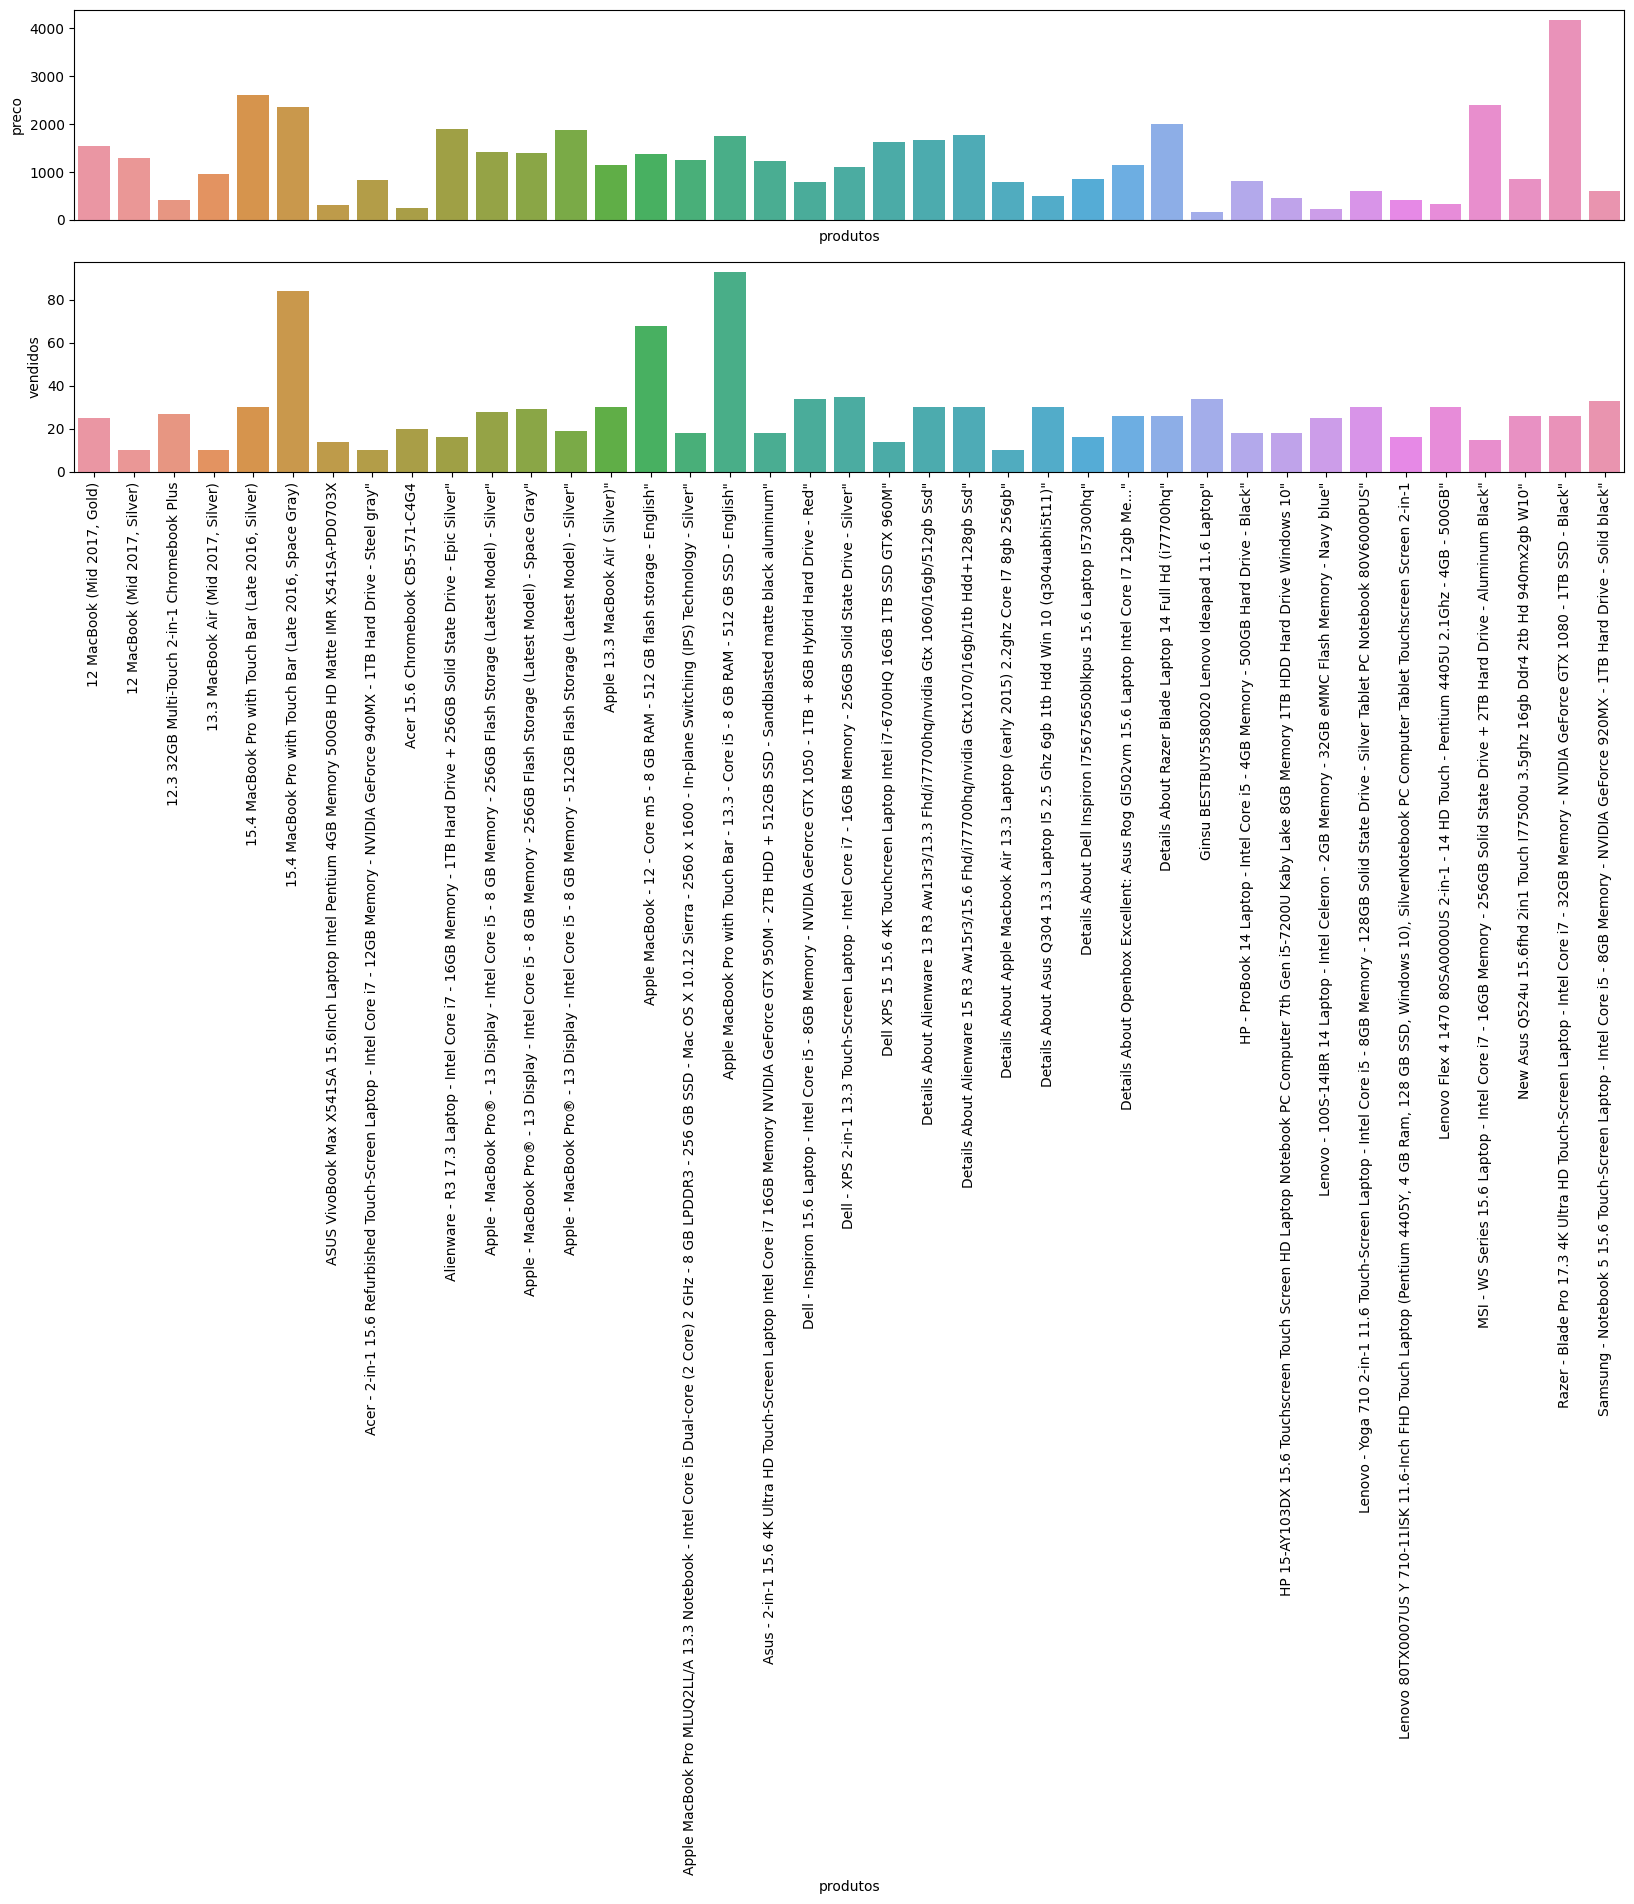

In [47]:
plt.figure(figsize=(20, 6))


plt.subplot(2,1,1)
aux7 = pd.DataFrame(df_x.apply( lambda x: x.median() )).reset_index()
aux7.columns = ['produtos', 'preco']
aux7.drop(0, axis='index', inplace=True)
sns.barplot(data=aux7, x="produtos", y="preco");
plt.xticks([])

plt.subplot(2,1,2)
aux8 = pd.DataFrame(df_y.apply( lambda x: x.sum() )).reset_index()
aux8.columns = ['produtos', 'vendidos']
aux8.drop(0, axis='index', inplace=True)
plt.xticks(rotation =90)
sns.barplot(data=aux8, x="produtos", y="vendidos");

In [48]:
a = ['week_number', '12 MacBook (Mid 2017, Gold)',
    '12 MacBook (Mid 2017, Silver)',
    '12.3 32GB Multi-Touch 2-in-1 Chromebook Plus',
    '13.3 MacBook Air (Mid 2017, Silver)',
    '15.4 MacBook Pro with Touch Bar (Late 2016, Silver)',
    '15.4 MacBook Pro with Touch Bar (Late 2016, Space Gray)',
    'ASUS VivoBook Max X541SA 15.6Inch Laptop Intel Pentium 4GB Memory 500GB HD Matte IMR X541SA-PD0703X',
    'Acer - 2-in-1 15.6 Refurbished Touch-Screen Laptop - Intel Core i7 - 12GB Memory - NVIDIA GeForce 940MX - 1TB Hard Drive - Steel gray"',
    'Acer 15.6 Chromebook CB5-571-C4G4',
    'Alienware - R3 17.3 Laptop - Intel Core i7 - 16GB Memory - 1TB Hard Drive + 256GB Solid State Drive - Epic Silver"',
    'Apple - MacBook Pro® - 13 Display - Intel Core i5 - 8 GB Memory - 256GB Flash Storage (Latest Model) - Silver"',
    'Apple - MacBook Pro® - 13 Display - Intel Core i5 - 8 GB Memory - 256GB Flash Storage (Latest Model) - Space Gray"',
    'Apple - MacBook Pro® - 13 Display - Intel Core i5 - 8 GB Memory - 512GB Flash Storage (Latest Model) - Silver"',
    'Apple 13.3 MacBook Air ( Silver)"',
    'Apple MacBook - 12 - Core m5 - 8 GB RAM - 512 GB flash storage - English"',
    'Apple MacBook Pro MLUQ2LL/A 13.3 Notebook - Intel Core i5 Dual-core (2 Core) 2 GHz - 8 GB LPDDR3 - 256 GB SSD - Mac OS X 10.12 Sierra - 2560 x 1600 - In-plane Switching (IPS) Technology - Silver"',
    'Apple MacBook Pro with Touch Bar - 13.3 - Core i5 - 8 GB RAM - 512 GB SSD - English"',
    'Asus - 2-in-1 15.6 4K Ultra HD Touch-Screen Laptop Intel Core i7 16GB Memory NVIDIA GeForce GTX 950M - 2TB HDD + 512GB SSD - Sandblasted matte black aluminum"',
    'Dell - Inspiron 15.6 Laptop - Intel Core i5 - 8GB Memory - NVIDIA GeForce GTX 1050 - 1TB + 8GB Hybrid Hard Drive - Red"',
    'Dell - XPS 2-in-1 13.3 Touch-Screen Laptop - Intel Core i7 - 16GB Memory - 256GB Solid State Drive - Silver"',
    'Dell XPS 15 15.6 4K Touchcreen Laptop Intel i7-6700HQ 16GB 1TB SSD GTX 960M"',
    'Details About Alienware 13 R3 Aw13r3/13.3 Fhd/i77700hq/nvidia Gtx 1060/16gb/512gb Ssd"',
    'Details About Alienware 15 R3 Aw15r3/15.6 Fhd/i77700hq/nvidia Gtx1070/16gb/1tb Hdd+128gb Ssd"',
    'Details About Apple Macbook Air 13.3 Laptop (early 2015) 2.2ghz Core I7 8gb 256gb"',
    'Details About Asus Q304 13.3 Laptop I5 2.5 Ghz 6gb 1tb Hdd Win 10 (q304uabhi5t11)"',
    'Details About Dell Inspiron I75675650blkpus 15.6 Laptop I57300hq"',
    'Details About Openbox Excellent: Asus Rog Gl502vm 15.6 Laptop Intel Core I7 12gb Me..."',
    'Details About Razer Blade Laptop 14 Full Hd (i77700hq"',
    'Ginsu BESTBUY5580020 Lenovo Ideapad 11.6 Laptop"',
    'HP - ProBook 14 Laptop - Intel Core i5 - 4GB Memory - 500GB Hard Drive - Black"',
    'HP 15-AY103DX 15.6 Touchscreen Touch Screen HD Laptop Notebook PC Computer 7th Gen i5-7200U Kaby Lake 8GB Memory 1TB HDD Hard Drive Windows 10"',
    'Lenovo - 100S-14IBR 14 Laptop - Intel Celeron - 2GB Memory - 32GB eMMC Flash Memory - Navy blue"',
    'Lenovo - Yoga 710 2-in-1 11.6 Touch-Screen Laptop - Intel Core i5 - 8GB Memory - 128GB Solid State Drive - Silver Tablet PC Notebook 80V6000PUS"',
    'Lenovo 80TX0007US Y 710-11ISK 11.6-Inch FHD Touch Laptop (Pentium 4405Y, 4 GB Ram, 128 GB SSD, Windows 10), SilverNotebook PC Computer Tablet Touchscreen Screen 2-in-1',
    'Lenovo Flex 4 1470 80SA0000US 2-in-1 - 14 HD Touch - Pentium 4405U 2.1Ghz - 4GB - 500GB"',
    'MSI - WS Series 15.6 Laptop - Intel Core i7 - 16GB Memory - 256GB Solid State Drive + 2TB Hard Drive - Aluminum Black"',
    'New Asus Q524u 15.6fhd 2in1 Touch I77500u 3.5ghz 16gb Ddr4 2tb Hd 940mx2gb W10"',
    'Razer - Blade Pro 17.3 4K Ultra HD Touch-Screen Laptop - Intel Core i7 - 32GB Memory - NVIDIA GeForce GTX 1080 - 1TB SSD - Black"',
    'Samsung - Notebook 5 15.6 Touch-Screen Laptop - Intel Core i5 - 8GB Memory - NVIDIA GeForce 920MX - 1TB Hard Drive - Solid black"']

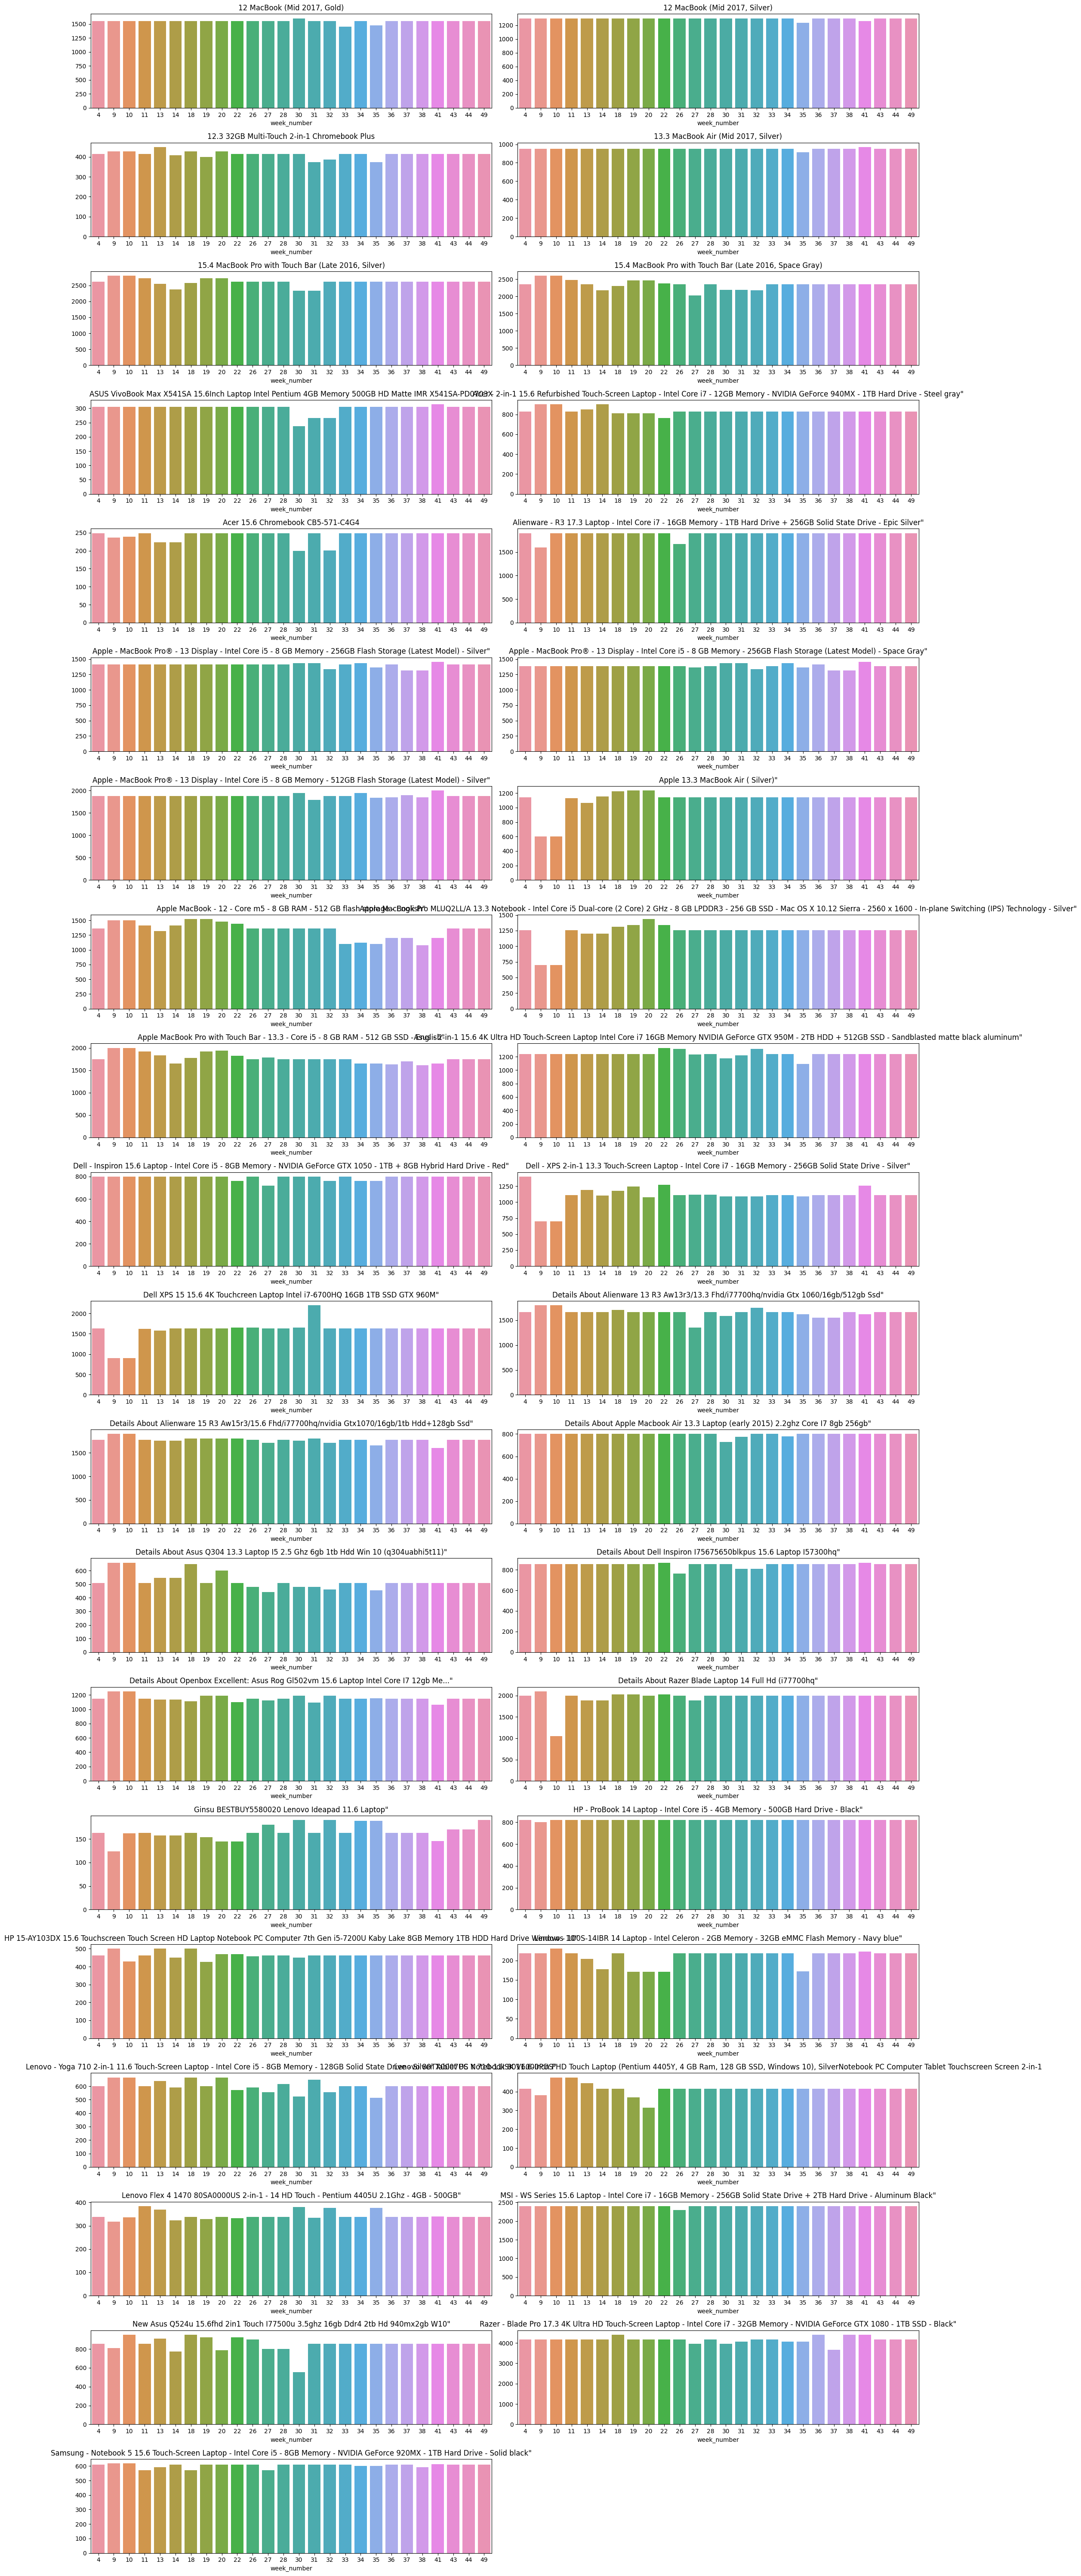

In [49]:
plt.figure(figsize=(20, 60))
for k in np.arange(1, len(df_x.columns), 1):
    plt.subplot(20,2,k)
    sns.barplot(data=df_x, x=df_x['week_number'], y=df_x[df_x.columns[k]]);
    plt.title(a[k])
    plt.ylabel('')
    plt.tight_layout()

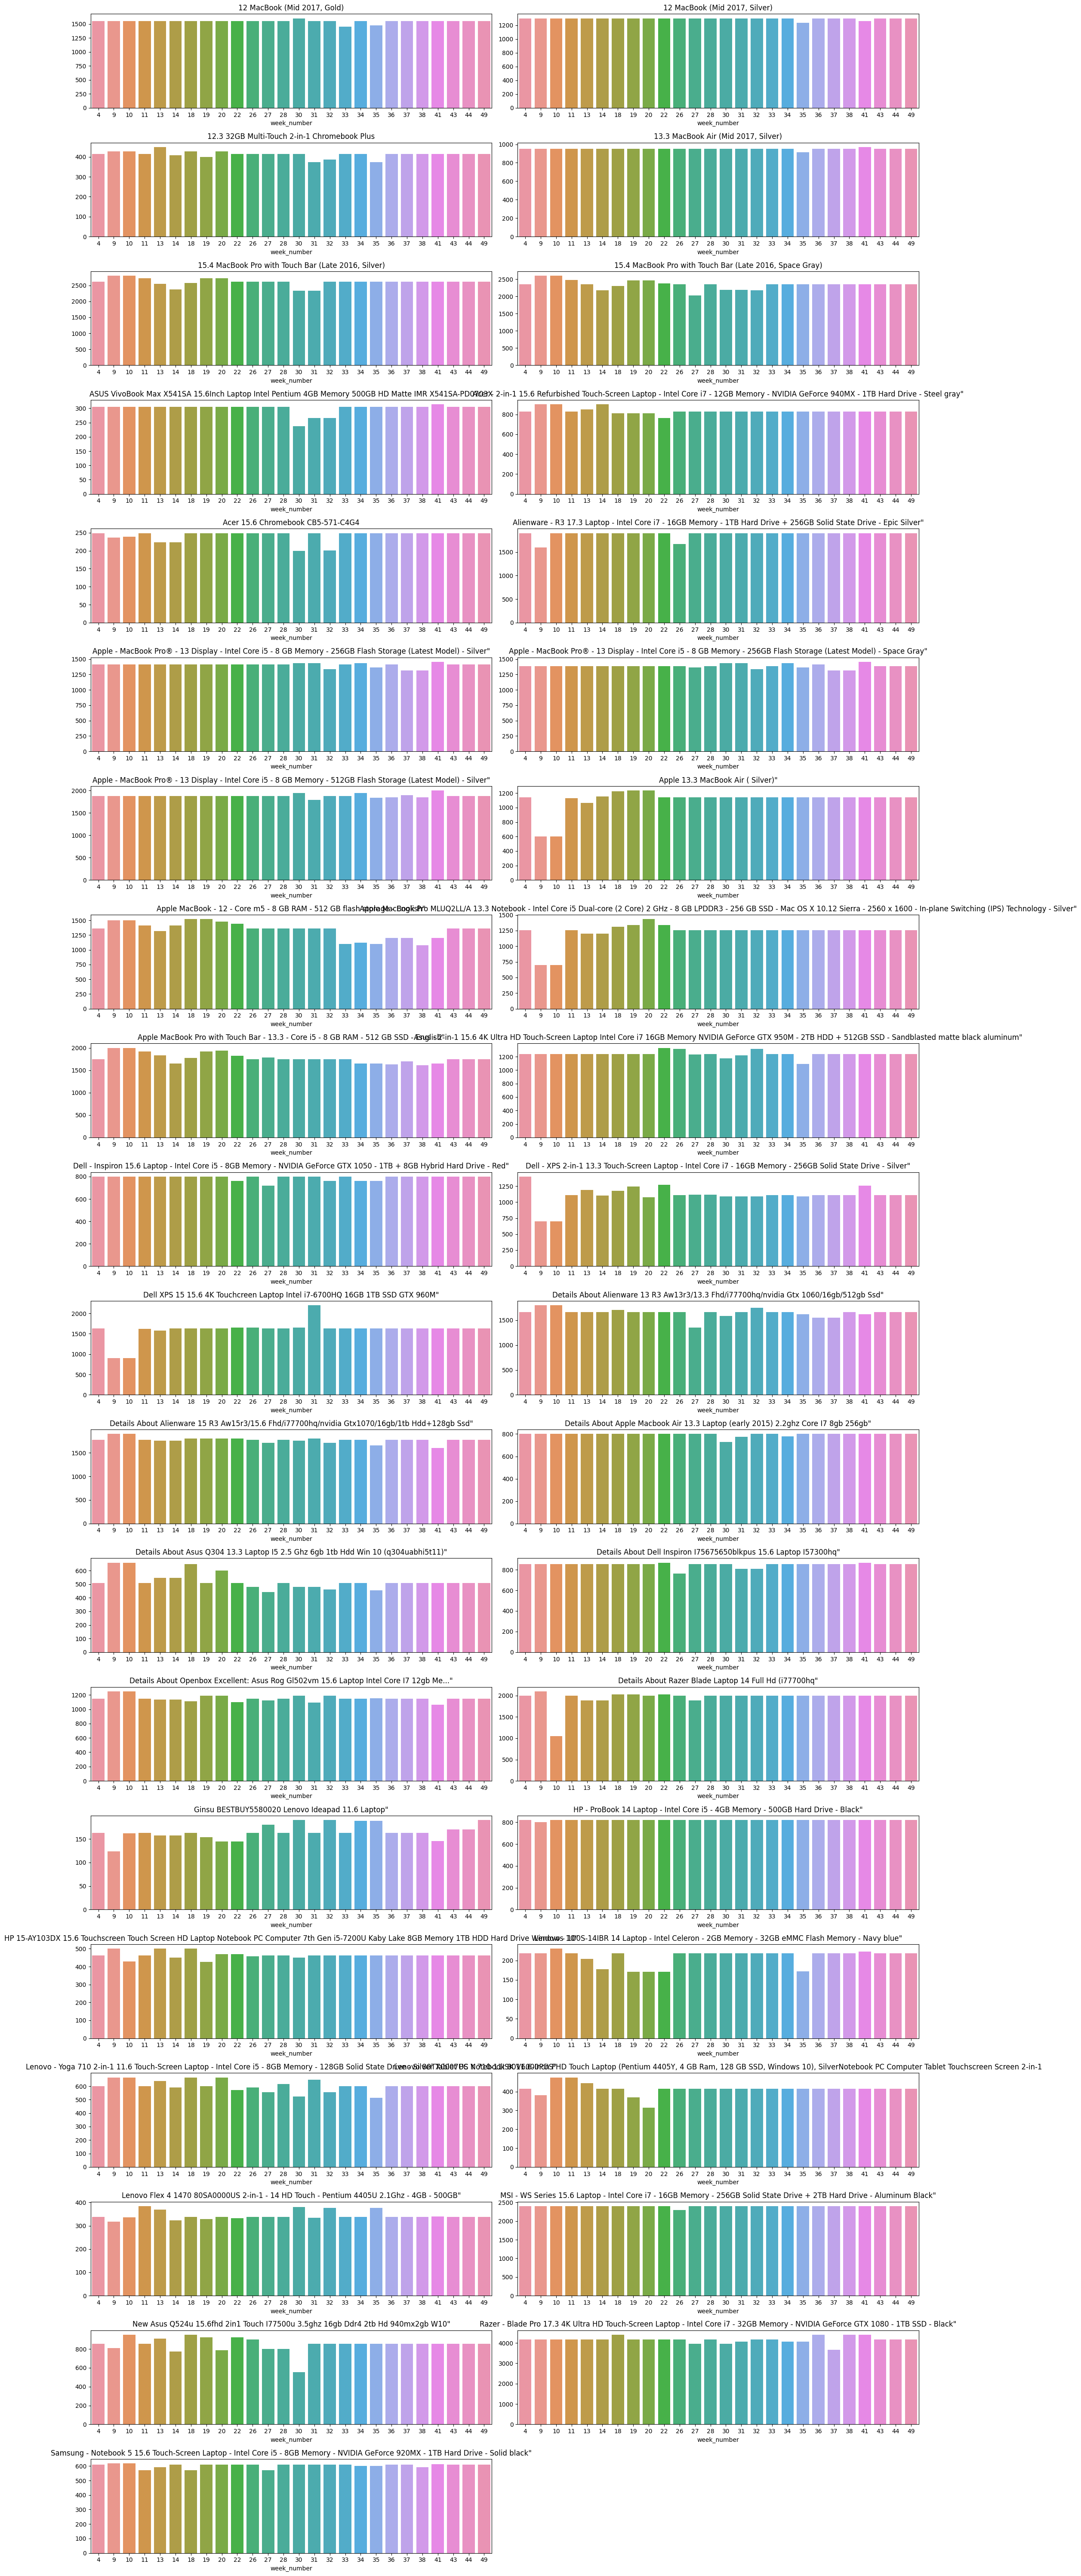

In [50]:
plt.figure(figsize=(20, 60))
for k in np.arange(1, len(df_y.columns), 1):
    plt.subplot(20,2,k)
    sns.barplot(data=df_y, x=df_y['week_number'], y=df_x[df_x.columns[k]]);
    plt.title(a[k])
    plt.ylabel('')
    plt.tight_layout()

# 6.0 Machine Learning Modelling 

## 6.1 Mínimos Quadrados Ordinários

### 6.1.1 laptop, computer

#### 6.1.1.1 12 MacBook (Mid 2017, Gold)

In [51]:
xv_laptop = x_values_laptop['12 MacBook (Mid 2017, Gold)']
yv_laptop = y_values_laptop['12 MacBook (Mid 2017, Gold)']
X_laptop = sm.add_constant(xv_laptop)
model = sm.OLS(yv_laptop, X_laptop)
result = model.fit()
print(result.summary())

                                 OLS Regression Results                                
Dep. Variable:     12 MacBook (Mid 2017, Gold)   R-squared:                       0.081
Model:                                     OLS   Adj. R-squared:                  0.042
Method:                          Least Squares   F-statistic:                     2.108
Date:                         Tue, 20 Jun 2023   Prob (F-statistic):              0.159
Time:                                 10:21:57   Log-Likelihood:                -50.564
No. Observations:                           26   AIC:                             105.1
Df Residuals:                               24   BIC:                             107.6
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------

#### 6.1.1.2 Mínimos Quadrados Ordinários - Todas as colunas

In [52]:
""" points_laptop = []
results_values_laptop = {
    "name": [],
    "price_elasticity": [],
    "price_mean": [],
    "quantity_mean": [],
    "intercept": [],
    "t_score":[],
    "slope": [],
    "coefficient_pvalue" : [],
    "rsquared": [],
}

for column in x_values_laptop.columns[1:]:
    #from pandas.core import datetools
    column_points = []
    for i in range(len(x_values_laptop[column])):
        if not np.isnan(x_values_laptop[column][i]) and not np.isnan(y_values_laptop[column][i]):
            column_points.append((x_values_laptop[column][i], y_values_laptop[column][i]))
    df = pd.DataFrame(list(column_points), columns= ['x_value', 'y_value'])

    #Linear Regression Model
    import statsmodels.api as sm
    x_value = df['x_value']
    y_value = df['y_value']
    X = sm.add_constant(x_value)
    model = sm.OLS(y_value, X)
    result = model.fit()
    
    #(Null Hypothesis test) Coefficient with a p value less than 0.05
    if result.f_pvalue < 0.05:
        
        rsquared = result.rsquared
        coefficient_pvalue = result.f_pvalue
        intercept, slope = result.params
        mean_price = np.mean(x_value)
        mean_quantity = np.mean(y_value)
        tintercept, t_score = result.tvalues
        
        #print(result.summary())
        
        #Price elasticity Formula
        price_elasticity = (slope)*(mean_price/mean_quantity)

  
        #Append results into dictionary for dataframe
        results_values_laptop["name"].append(column)
        results_values_laptop["price_elasticity"].append(price_elasticity)
        results_values_laptop["price_mean"].append(mean_price)
        results_values_laptop["quantity_mean"].append(mean_quantity)
        results_values_laptop["intercept"].append(intercept)
        results_values_laptop['t_score'].append(t_score)
        results_values_laptop["slope"].append(slope)
        results_values_laptop["coefficient_pvalue"].append(coefficient_pvalue)
        results_values_laptop["rsquared"].append(rsquared)
        
final_df_laptop = pd.DataFrame.from_dict(results_values_laptop) """

' points_laptop = []\nresults_values_laptop = {\n    "name": [],\n    "price_elasticity": [],\n    "price_mean": [],\n    "quantity_mean": [],\n    "intercept": [],\n    "t_score":[],\n    "slope": [],\n    "coefficient_pvalue" : [],\n    "rsquared": [],\n}\n\nfor column in x_values_laptop.columns[1:]:\n    #from pandas.core import datetools\n    column_points = []\n    for i in range(len(x_values_laptop[column])):\n        if not np.isnan(x_values_laptop[column][i]) and not np.isnan(y_values_laptop[column][i]):\n            column_points.append((x_values_laptop[column][i], y_values_laptop[column][i]))\n    df = pd.DataFrame(list(column_points), columns= [\'x_value\', \'y_value\'])\n\n    #Linear Regression Model\n    import statsmodels.api as sm\n    x_value = df[\'x_value\']\n    y_value = df[\'y_value\']\n    X = sm.add_constant(x_value)\n    model = sm.OLS(y_value, X)\n    result = model.fit()\n    \n    #(Null Hypothesis test) Coefficient with a p value less than 0.05\n    if resu

In [53]:
points_laptop = []
results_values_laptop = {
    "name": [],
    "price_elasticity": [],
    "price_mean": [],
    "quantity_mean": [],
    "intercept": [],
    "t_score":[],
    "slope": [],
    "coefficient_pvalue" : [],
    "rsquared": [],
}

for column in x_values_laptop.columns[1:]:
    #from pandas.core import datetools
    column_points = []
    for i in range(len(x_values_laptop[column])):
        column_points.append((x_values_laptop[column][i], y_values_laptop[column][i]))
    df = pd.DataFrame(list(column_points), columns= ['x_value', 'y_value'])

    #Linear Regression Model
    import statsmodels.api as sm
    x_value = df['x_value']
    y_value = df['y_value']
    X = sm.add_constant(x_value)
    model = sm.OLS(y_value, X)
    result = model.fit()
    
    #(Null Hypothesis test) Coefficient with a p value less than 0.05
    if result.f_pvalue < 0.05:
        
        rsquared = result.rsquared
        coefficient_pvalue = result.f_pvalue
        intercept, slope = result.params
        mean_price = np.mean(x_value)
        mean_quantity = np.mean(y_value)
        tintercept, t_score = result.tvalues
        
        #Price elasticity Formula
        price_elasticity = (slope)*(mean_price/mean_quantity)

  
        #Append results into dictionary for dataframe
        results_values_laptop["name"].append(column)
        results_values_laptop["price_elasticity"].append(price_elasticity)
        results_values_laptop["price_mean"].append(mean_price)
        results_values_laptop["quantity_mean"].append(mean_quantity)
        results_values_laptop["intercept"].append(intercept)
        results_values_laptop['t_score'].append(t_score)
        results_values_laptop["slope"].append(slope)
        results_values_laptop["coefficient_pvalue"].append(coefficient_pvalue)
        results_values_laptop["rsquared"].append(rsquared)
        
final_df_laptop = pd.DataFrame.from_dict(results_values_laptop)

In [54]:
df_elasticity_laptop = final_df_laptop[['name','price_elasticity','t_score','coefficient_pvalue','slope','price_mean','quantity_mean','intercept','rsquared']]
df_elasticity_laptop

,name,price_elasticity,t_score,coefficient_pvalue,slope,price_mean,quantity_mean,intercept,rsquared
0,"12 MacBook (Mid 2017, Silver)",-65.115595,-2.419041,0.023508,-0.019325,1295.990000,0.384615,25.429075,0.196027
1,ASUS VivoBook Max X541SA 15.6Inch Laptop Intel...,-16.039643,-3.070091,0.005251,-0.028816,299.720769,0.538462,9.175192,0.281984
2,Acer 15.6 Chromebook CB5-571-C4G4,-8.432545,-2.151157,0.041743,-0.026751,242.479231,0.769231,7.255804,0.161645
3,Apple MacBook Pro MLUQ2LL/A 13.3 Notebook - In...,-6.018642,-2.726301,0.011774,-0.003404,1224.221154,0.692308,4.859060,0.236464
4,Dell - Inspiron 15.6 Laptop - Intel Core i5 - ...,-23.203537,-3.421366,0.002237,-0.038372,790.759231,1.307692,31.650779,0.327839
5,Details About Apple Macbook Air 13.3 Laptop (e...,-68.165723,-5.001078,0.000041,-0.032957,795.509231,0.384615,26.602201,0.510312
6,Lenovo - 100S-14IBR 14 Laptop - Intel Celeron ...,-6.049399,-3.037382,0.005677,-0.027743,209.663077,0.961538,6.778268,0.277667


In [55]:
df_elasticity_laptop.to_csv('../data/finals/elasticidade_laptop.csv')

# 7.0 Cálculo da Elasticidade

In [56]:
df_elasticity_laptop

,name,price_elasticity,t_score,coefficient_pvalue,slope,price_mean,quantity_mean,intercept,rsquared
0,"12 MacBook (Mid 2017, Silver)",-65.115595,-2.419041,0.023508,-0.019325,1295.990000,0.384615,25.429075,0.196027
1,ASUS VivoBook Max X541SA 15.6Inch Laptop Intel...,-16.039643,-3.070091,0.005251,-0.028816,299.720769,0.538462,9.175192,0.281984
2,Acer 15.6 Chromebook CB5-571-C4G4,-8.432545,-2.151157,0.041743,-0.026751,242.479231,0.769231,7.255804,0.161645
3,Apple MacBook Pro MLUQ2LL/A 13.3 Notebook - In...,-6.018642,-2.726301,0.011774,-0.003404,1224.221154,0.692308,4.859060,0.236464
4,Dell - Inspiron 15.6 Laptop - Intel Core i5 - ...,-23.203537,-3.421366,0.002237,-0.038372,790.759231,1.307692,31.650779,0.327839
5,Details About Apple Macbook Air 13.3 Laptop (e...,-68.165723,-5.001078,0.000041,-0.032957,795.509231,0.384615,26.602201,0.510312
6,Lenovo - 100S-14IBR 14 Laptop - Intel Celeron ...,-6.049399,-3.037382,0.005677,-0.027743,209.663077,0.961538,6.778268,0.277667


## 7.1 laptop, computer

In [57]:
""" df_elasticity_laptop['ranking'] = df_elasticity_laptop.loc[ : ,'price_elasticity'].rank( ascending = True).astype(int)
df_elasticity_laptop.sort_values('price_elasticity', ascending =False, inplace = True)
plt.figure(figsize = (12,5), dpi = 80)
plt.hlines(y = df_elasticity_laptop['ranking'] , xmin = 0, xmax = df_elasticity_laptop['price_elasticity'], alpha = 0.5, linewidth = 3)

 #Add elasticity labels
for x, y, tex in zip(df_elasticity_laptop['price_elasticity'], df_elasticity_laptop['ranking'], df_elasticity_laptop['price_elasticity']):
    plt.text(x, y, round(tex, 2), horizontalalignment='right' if x < 0 else 'left', 
             verticalalignment='center', fontdict={'color':'red' if x < 0 else 'green', 'size':10})
    
# Axis and title
plt.gca().set(ylabel= 'Ranking Number', xlabel= 'Price Elasticity')
plt.yticks(df_elasticity_laptop['ranking'])
plt.title('price_elasticity' , fontdict={'size':13})
plt.grid(linestyle='--', alpha=0.5)
plt.show()  """

" df_elasticity_laptop['ranking'] = df_elasticity_laptop.loc[ : ,'price_elasticity'].rank( ascending = True).astype(int)\ndf_elasticity_laptop.sort_values('price_elasticity', ascending =False, inplace = True)\nplt.figure(figsize = (12,5), dpi = 80)\nplt.hlines(y = df_elasticity_laptop['ranking'] , xmin = 0, xmax = df_elasticity_laptop['price_elasticity'], alpha = 0.5, linewidth = 3)\n\n #Add elasticity labels\nfor x, y, tex in zip(df_elasticity_laptop['price_elasticity'], df_elasticity_laptop['ranking'], df_elasticity_laptop['price_elasticity']):\n    plt.text(x, y, round(tex, 2), horizontalalignment='right' if x < 0 else 'left', \n             verticalalignment='center', fontdict={'color':'red' if x < 0 else 'green', 'size':10})\n    \n# Axis and title\nplt.gca().set(ylabel= 'Ranking Number', xlabel= 'Price Elasticity')\nplt.yticks(df_elasticity_laptop['ranking'])\nplt.title('price_elasticity' , fontdict={'size':13})\nplt.grid(linestyle='--', alpha=0.5)\nplt.show()  "

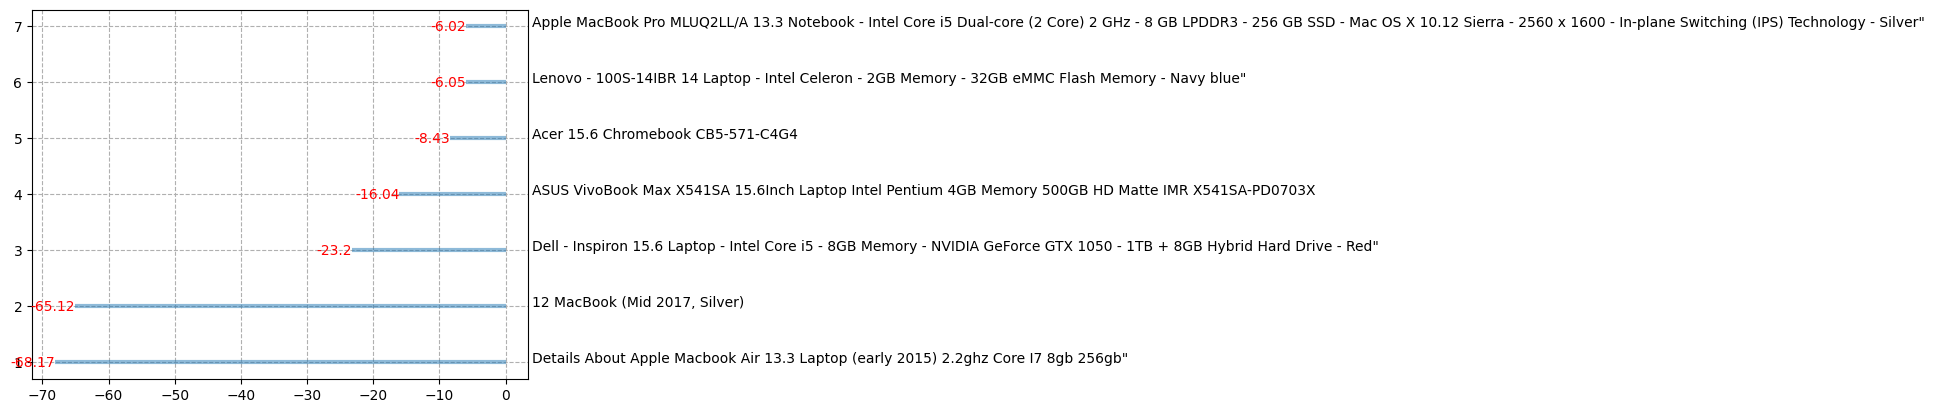

In [93]:
df_elasticity_laptop['ranking'] = df_elasticity_laptop.loc[ : ,'price_elasticity'].rank( ascending = True).astype(int)
df_elasticity_laptop = df_elasticity_laptop.reset_index(drop = True)
fig, ax = plt.subplots()
#ax.figure(figsize = (12,4))
ax.hlines(y = df_elasticity_laptop['ranking'] , xmin = 0, xmax = df_elasticity_laptop['price_elasticity'], alpha = 0.5, linewidth = 3)

for name, p in zip(df_elasticity_laptop['name'], df_elasticity_laptop['ranking']):
    ax.text(4, p, name)

for x, y, s in zip(df_elasticity_laptop['price_elasticity'], df_elasticity_laptop['ranking'], df_elasticity_laptop['price_elasticity']):
    ax.text(x, y, round(s, 2), horizontalalignment='right' if x < 0 else 'left', 
             verticalalignment='center', fontdict={'color':'red' if x < 0 else 'green', 'size':10})
    
#ax.gca().set(ylabel= 'Ranking Number', xlabel= 'Price Elasticity')
#ax.title('Price Elasticity' , fontdict={'size':13})
ax.grid(linestyle='--')

/tmp/ipykernel_1273/552767853.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elasticity_laptop['ranking'] = df_elasticity_laptop.loc[ : ,'price_elasticity'].rank( ascending = True).astype(int)


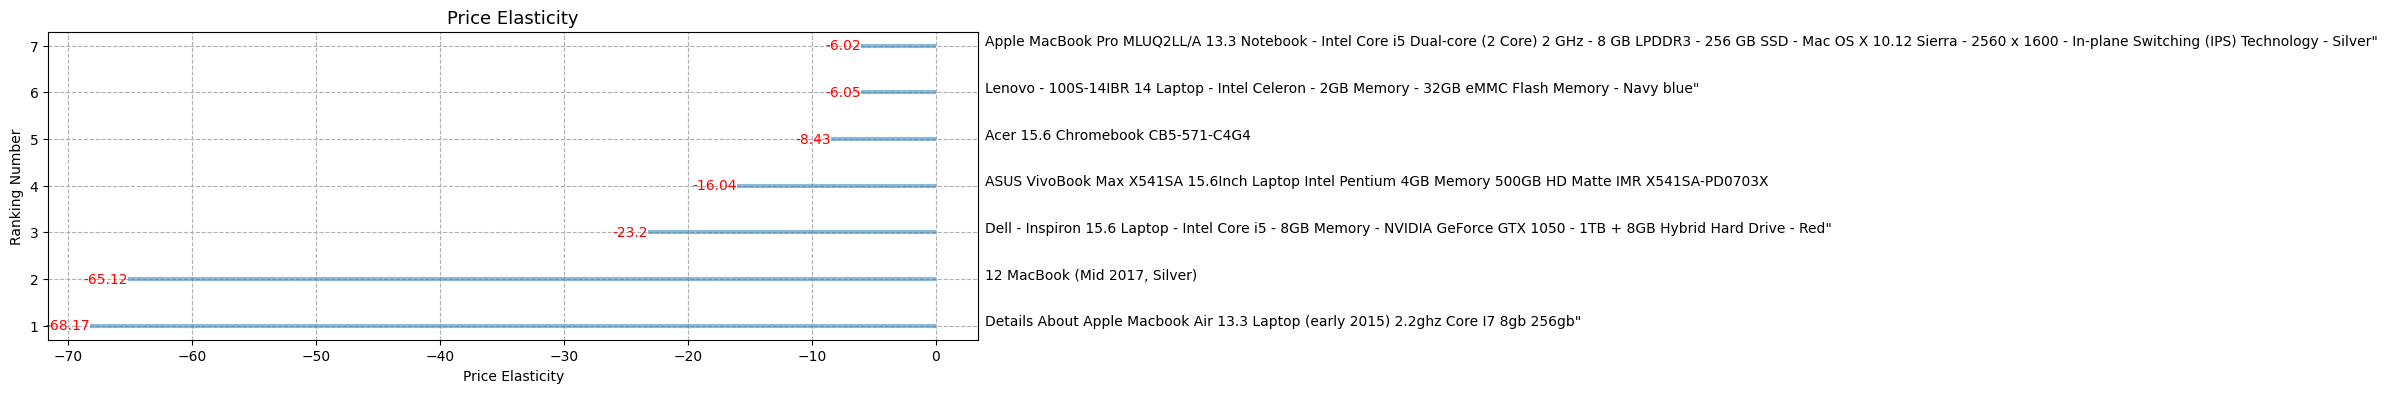

In [58]:
df_elasticity_laptop['ranking'] = df_elasticity_laptop.loc[ : ,'price_elasticity'].rank( ascending = True).astype(int)
df_elasticity_laptop = df_elasticity_laptop.reset_index(drop = True)
plt.figure(figsize = (12,4))
plt.hlines(y = df_elasticity_laptop['ranking'] , xmin = 0, xmax = df_elasticity_laptop['price_elasticity'], alpha = 0.5, linewidth = 3)

for name, p in zip(df_elasticity_laptop['name'], df_elasticity_laptop['ranking']):
    plt.text(4, p, name)

 #Add elasticity labels
for x, y, s in zip(df_elasticity_laptop['price_elasticity'], df_elasticity_laptop['ranking'], df_elasticity_laptop['price_elasticity']):
    plt.text(x, y, round(s, 2), horizontalalignment='right' if x < 0 else 'left', 
             verticalalignment='center', fontdict={'color':'red' if x < 0 else 'green', 'size':10})
    
plt.gca().set(ylabel= 'Ranking Number', xlabel= 'Price Elasticity')
plt.title('Price Elasticity' , fontdict={'size':13})
plt.grid(linestyle='--')

In [59]:
df_order_laptop = df_elasticity_laptop[['ranking', 'name', 'price_elasticity']].sort_values(by='price_elasticity', ascending=False)
df_order_laptop

,ranking,name,price_elasticity
3,7,Apple MacBook Pro MLUQ2LL/A 13.3 Notebook - In...,-6.018642
6,6,Lenovo - 100S-14IBR 14 Laptop - Intel Celeron ...,-6.049399
2,5,Acer 15.6 Chromebook CB5-571-C4G4,-8.432545
1,4,ASUS VivoBook Max X541SA 15.6Inch Laptop Intel...,-16.039643
4,3,Dell - Inspiron 15.6 Laptop - Intel Core i5 - ...,-23.203537
0,2,"12 MacBook (Mid 2017, Silver)",-65.115595
5,1,Details About Apple Macbook Air 13.3 Laptop (e...,-68.165723


# 8.0 Business Performance

In [60]:
resultado_faturamento = {
    "name": [],
    "faturamento_atual": [],
    "faturamento_reducao": [],
    "perda_faturamento": [],
    "faturamento_novo": [],
    "variacao_faturamento":[],
    "variacao_percentual": []
}



for i in range(len(df_order_laptop)):
    preco_atual_medio = df_x[df_order_laptop['name'][i]].mean()
    demanda_atual = df_y[df_order_laptop['name'][i]].sum()

    reducao_preco = preco_atual_medio*0.9
    aumento_demanda = -0.1*df_order_laptop['price_elasticity'][i]

    demanda_nova = aumento_demanda*demanda_atual

    faturamento_atual = round(preco_atual_medio*demanda_atual, 2)
    faturamento_novo = round(reducao_preco*demanda_nova, 2)

    faturamento_reducao = round(faturamento_atual*0.9, 2)

    perda_faturamento = round(faturamento_atual-faturamento_reducao, 2)

    variacao_faturamento = round(faturamento_novo-faturamento_atual, 2)

    variacao_percentual = round(((faturamento_novo-faturamento_atual)/faturamento_atual)*100, 2)
    

    resultado_faturamento["name"].append(df_order_laptop['name'][i])
    resultado_faturamento["faturamento_atual"].append(faturamento_atual)
    resultado_faturamento["faturamento_reducao"].append(faturamento_reducao)
    resultado_faturamento["perda_faturamento"].append(perda_faturamento)
    resultado_faturamento["faturamento_novo"].append(faturamento_novo)
    resultado_faturamento["variacao_faturamento"].append(variacao_faturamento)
    resultado_faturamento["variacao_percentual"].append(variacao_percentual)

resultado = pd.DataFrame(resultado_faturamento)

resultado

,name,faturamento_atual,faturamento_reducao,perda_faturamento,faturamento_novo,variacao_faturamento,variacao_percentual
0,"12 MacBook (Mid 2017, Silver)",12959.90,11663.91,1295.99,75950.24,62990.34,486.04
1,ASUS VivoBook Max X541SA 15.6Inch Laptop Intel...,4196.09,3776.48,419.61,6057.34,1861.25,44.36
2,Acer 15.6 Chromebook CB5-571-C4G4,4849.58,4364.62,484.96,3680.49,-1169.09,-24.11
3,Apple MacBook Pro MLUQ2LL/A 13.3 Notebook - In...,22035.98,19832.38,2203.60,11936.40,-10099.58,-45.83
4,Dell - Inspiron 15.6 Laptop - Intel Core i5 - ...,26885.81,24197.23,2688.58,56146.14,29260.33,108.83
5,Details About Apple Macbook Air 13.3 Laptop (e...,7955.09,7159.58,795.51,48803.82,40848.73,513.49
6,Lenovo - 100S-14IBR 14 Laptop - Intel Celeron ...,5241.58,4717.42,524.16,2853.75,-2387.83,-45.56


In [61]:
resultado.to_csv('../data/finals/businesss_performance.csv')

In [62]:
resultado['faturamento_novo'].sum() - resultado['faturamento_atual'].sum()

121304.15

In [63]:
df_posit = resultado[resultado['variacao_faturamento'] > 0]
df_posit['faturamento_novo'].sum() - df_posit['faturamento_atual'].sum()

134960.65000000002

In [64]:
preco_atual_medio = df_x['Details About Apple Macbook Air 13.3 Laptop (early 2015) 2.2ghz Core I7 8gb 256gb"'].mean()
demanda_atual = df_y['Details About Apple Macbook Air 13.3 Laptop (early 2015) 2.2ghz Core I7 8gb 256gb"'].sum()

reducao_preco = preco_atual_medio*0.9
aumento_demanda = -0.1*df_order_laptop['price_elasticity'][5]

demanda_nova = aumento_demanda*demanda_atual

faturamento_atual = preco_atual_medio*demanda_atual
faturamento_novo = reducao_preco*demanda_nova

faturamento_reducao = faturamento_atual*0.9

print(f'O faturamento atual é R$ {round(faturamento_atual, 2)}, com a redução de 10% sugerida seria R$ {round(faturamento_reducao, 2)}, portanto diminuíria R${round(faturamento_atual-faturamento_reducao, 2) }.')
print(f'Mas com o aumento da demanda devido a redução, o faturamento seria R$ {round(faturamento_novo, 2)}, gerando um um incremento de R${round(faturamento_novo-faturamento_atual, 2)} ou {round(((faturamento_novo-faturamento_atual)/faturamento_atual)*100, 2)} % no faturamento')

O faturamento atual é R$ 7955.09, com a redução de 10% sugerida seria R$ 7159.58, portanto diminuíria R$795.51.
Mas com o aumento da demanda devido a redução, o faturamento seria R$ 48803.82, gerando um um incremento de R$40848.72 ou 513.49 % no faturamento


# 9.0 Cross Price Elasticity

## 9.1 12 MacBook (Mid 2017, Gold)

In [65]:
#pegar todos os X_values
new_df = df_x.copy()

#pegue y_value com o mesmo nome de coluna
new_df['y_value-' + '12 MacBook (Mid 2017, Gold)'] = df_y['12 MacBook (Mid 2017, Gold)']

multi_xvalues = new_df.loc[:, new_df.columns[1:-1]]
multi_yvalue = new_df.loc[:, new_df.columns[-1]]

multi_yvalue.head()

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: y_value-12 MacBook (Mid 2017, Gold), dtype: float64

In [66]:
#pegar todos os X_values
new_df = df_x.copy()
#pegue y_value com o mesmo nome de coluna
new_df['y_value-' + '12 MacBook (Mid 2017, Gold)'] = df_y['12 MacBook (Mid 2017, Gold)']

multi_xvalues = new_df.loc[:, new_df.columns[1:-1]]
multi_yvalue = new_df.loc[:, new_df.columns[-1]]

#obter valores médios de preço por produto
mean_xvalues = np.mean(multi_xvalues)
#obter a quantidade média para o valor y
mean_yvalue = np.mean(multi_yvalue)

# regressão multilinear
X = sm.add_constant(multi_xvalues)
model = sm.OLS(multi_yvalue, X, missing='drop')
result = model.fit()

#Obter resultados
results_summary = result.summary()
#obter pvalues ​​de cada coeficiente
pvalue = result.pvalues

#transformar o resultado do resumo em uma tabela
results_as_html = results_summary.tables[1].as_html()

new_dataframe = pd.read_html(results_as_html, header=0, index_col=0)[0]

#adicione o valor de p à tabela
new_dataframe['p_value']= pvalue

#definir o nome do produto como índice
new_dataframe.index.name = 'name'
new_dataframe.reset_index()

#obtenha a média do preço do nome de cada produto
new_dataframe['mean'] = mean_xvalues

#executar fórmula de preço cruzado
new_dataframe['price_elasticity'] = np.round((new_dataframe.coef) * (new_dataframe['mean'] / mean_yvalue), 2)

new_dataframe = new_dataframe.reset_index()
pvalue_significant = new_dataframe['p_value']

#Verifique a hipótese nula para coeficiente ou valor de inclinação por produto
new_dataframe['12 MacBook (Mid 2017, Gold)'+'_CPE'] = np.where((pvalue_significant > .05), 'No effect', new_dataframe['price_elasticity'])
new_dataframe = new_dataframe.dropna()

/home/alexsandro/.pyenv/versions/3.10-dev/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


In [67]:
results_summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     OLS Regression Results                                    
===============================================================================================
Dep. Variable:     y_value-12 MacBook (Mid 2017, Gold)   R-squared:                       1.000
Model:                                             OLS   Adj. R-squared:                  1.000
Method:                                  Least Squares   F-statistic:                 4.010e+26
Date:                                 Tue, 20 Jun 2023   Prob (F-statistic):           3.94e-14
Time:                                         10:21:58   Log-Likelihood:                 785.98
No. Observations:                                   26   AIC:                            -1522.
Df Residuals:                                        1   BIC:                            -1491.
Df Model:                                           24                                         
Covariance Type:                             nonrobust                                         
=======================================================================================================================================================================================================================================================================
                                                                                                                                                                                                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
const                                                                                                                                                                                                9.786e-06   1.74e-18   5.61e+12      0.000    9.79e-06    9.79e-06
12 MacBook (Mid 2017, Gold)                                                                                                                                                                            -0.0058   1.31e-15  -4.46e+12      0.000      -0.006      -0.006
12 MacBook (Mid 2017, Silver)                                                                                                                                                                          -0.0078   7.32e-16  -1.07e+13      0.000      -0.008      -0.008
12.3 32GB Multi-Touch 2-in-1 Chromebook Plus                                                                                                                                                           -0.0221   1.33e-15  -1.66e+13      0.000      -0.022      -0.022
13.3 MacBook Air (Mid 2017, Silver)                                                                                                                                                                     0.0009    3.8e-16   2.28e+12      0.000       0.001       0.001
15.4 MacBook Pro with Touch Bar (Late 2016, Silver)                                                                                                                                                     0.0007    6.7e-16   1.04e+12      0.000       0.001       0.001
15.4 MacBook Pro with Touch Bar (Late 2016, Space Gray)                                                                                                                                                 0.0039   7.16e-16   5.41e+12      0.000       0.004       0.004
ASUS VivoBook Max X541SA 15.6Inch Laptop Intel Pentium 4GB Memory 500GB HD Matte IMR X541SA-PD0703X                                                                                                    -0.0114   5.98e-16   -1.9e+13      0.000      -0.011     

## 9.2 Cross Price Elasticity - Todos os produtos

In [68]:
def crossprice(df_x, df_y, column_name):
    import statsmodels.api as sm

    #pegar todos os X_values
    new_df = df_x.copy()
    #pegue y_value com o mesmo nome de coluna
    new_df['y_value-' + column_name] = df_y[column_name]

    multi_xvalues = new_df.loc[:, new_df.columns[1:-1]]
    multi_yvalue = new_df.loc[:, new_df.columns[-1]]

    #obter valores médios de preço por produto
    mean_xvalues = np.mean(multi_xvalues)
    #obter a quantidade média para o valor y
    mean_yvalue = np.mean(multi_yvalue)

    # regressão multilinear
    X = sm.add_constant(multi_xvalues)
    model = sm.OLS(multi_yvalue, X, missing='drop')
    result = model.fit()

    #Obter resultados
    results_summary = result.summary()
    #obter pvalues ​​de cada coeficiente
    pvalue = result.pvalues

    #transformar o resultado do resumo em uma tabela
    results_as_html = results_summary.tables[1].as_html()

    new_dataframe = pd.read_html(results_as_html, header=0, index_col=0)[0]

    #adicione o valor de p à tabela
    new_dataframe['p_value']= pvalue

    #definir o nome do produto como índice
    new_dataframe.index.name = 'name'
    new_dataframe.reset_index()

    #obtenha a média do preço do nome de cada produto
    new_dataframe['mean'] = mean_xvalues

    #executar fórmula de preço cruzado
    new_dataframe['price_elasticity'] = np.round((new_dataframe.coef) * (new_dataframe['mean'] / mean_yvalue), 2)

    new_dataframe = new_dataframe.reset_index()
    pvalue_significant = new_dataframe['p_value']

    #Verifique a hipótese nula para coeficiente ou valor de inclinação por produto
    new_dataframe[column_name + '_CPE'] = np.where((pvalue_significant > .05), 'No effect', new_dataframe['price_elasticity'])
    new_dataframe = new_dataframe.dropna()

    return new_dataframe[['name', column_name + '_CPE']]

In [69]:
#criando uma matriz da elasticidade de cross price
result_df = pd.DataFrame()
for column in df_x.columns[1:]:
    result_df[['name', column + '_CPE']] = crossprice(df_x, df_y, column)
""" result_df = result_df.dropna()
    result_df[column + '_CPE'] = pd.to_numeric(result_df[column + '_CPE'], errors='coerce').fillna(0) """

/home/alexsandro/.pyenv/versions/3.10-dev/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/home/alexsandro/.pyenv/versions/3.10-dev/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/home/alexsandro/.pyenv/versions/3.10-dev/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  re

/home/alexsandro/.pyenv/versions/3.10-dev/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/home/alexsandro/.pyenv/versions/3.10-dev/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/home/alexsandro/.pyenv/versions/3.10-dev/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  re

" result_df = result_df.dropna()\n    result_df[column + '_CPE'] = pd.to_numeric(result_df[column + '_CPE'], errors='coerce').fillna(0) "

In [70]:
result_df = result_df.set_index('name')

In [71]:
result_df.head()

,"12 MacBook (Mid 2017, Gold)_CPE","12 MacBook (Mid 2017, Silver)_CPE",12.3 32GB Multi-Touch 2-in-1 Chromebook Plus_CPE,"13.3 MacBook Air (Mid 2017, Silver)_CPE","15.4 MacBook Pro with Touch Bar (Late 2016, Silver)_CPE","15.4 MacBook Pro with Touch Bar (Late 2016, Space Gray)_CPE",ASUS VivoBook Max X541SA 15.6Inch Laptop Intel Pentium 4GB Memory 500GB HD Matte IMR X541SA-PD0703X_CPE,"Acer - 2-in-1 15.6 Refurbished Touch-Screen Laptop - Intel Core i7 - 12GB Memory - NVIDIA GeForce 940MX - 1TB Hard Drive - Steel gray""_CPE",Acer 15.6 Chromebook CB5-571-C4G4_CPE,"Alienware - R3 17.3 Laptop - Intel Core i7 - 16GB Memory - 1TB Hard Drive + 256GB Solid State Drive - Epic Silver""_CPE",...,"HP - ProBook 14 Laptop - Intel Core i5 - 4GB Memory - 500GB Hard Drive - Black""_CPE","HP 15-AY103DX 15.6 Touchscreen Touch Screen HD Laptop Notebook PC Computer 7th Gen i5-7200U Kaby Lake 8GB Memory 1TB HDD Hard Drive Windows 10""_CPE","Lenovo - 100S-14IBR 14 Laptop - Intel Celeron - 2GB Memory - 32GB eMMC Flash Memory - Navy blue""_CPE","Lenovo - Yoga 710 2-in-1 11.6 Touch-Screen Laptop - Intel Core i5 - 8GB Memory - 128GB Solid State Drive - Silver Tablet PC Notebook 80V6000PUS""_CPE","Lenovo 80TX0007US Y 710-11ISK 11.6-Inch FHD Touch Laptop (Pentium 4405Y, 4 GB Ram, 128 GB SSD, Windows 10), SilverNotebook PC Computer Tablet Touchscreen Screen 2-in-1_CPE","Lenovo Flex 4 1470 80SA0000US 2-in-1 - 14 HD Touch - Pentium 4405U 2.1Ghz - 4GB - 500GB""_CPE","MSI - WS Series 15.6 Laptop - Intel Core i7 - 16GB Memory - 256GB Solid State Drive + 2TB Hard Drive - Aluminum Black""_CPE","New Asus Q524u 15.6fhd 2in1 Touch I77500u 3.5ghz 16gb Ddr4 2tb Hd 940mx2gb W10""_CPE","Razer - Blade Pro 17.3 4K Ultra HD Touch-Screen Laptop - Intel Core i7 - 32GB Memory - NVIDIA GeForce GTX 1080 - 1TB SSD - Black""_CPE","Samsung - Notebook 5 15.6 Touch-Screen Laptop - Intel Core i5 - 8GB Memory - NVIDIA GeForce 920MX - 1TB Hard Drive - Solid black""_CPE"
name,,,,,,,,,,,,,,,,,,,,,
"12 MacBook (Mid 2017, Gold)",-9.33,18.5,-4.17,-10.06,3.49,4.88,10.34,1.61,4.22,15.08,...,10.28,1.34,0.32,-5.5,14.08,-3.89,12.34,-4.49,7.27,19.02
"12 MacBook (Mid 2017, Silver)",-10.51,-10.45,-10.48,-17.18,-7.97,-7.54,-10.59,-7.41,-5.73,-5.69,...,-8.99,-7.11,-8.76,-12.13,-3.16,-10.11,-11.23,-11.02,-11.53,-8.17
12.3 32GB Multi-Touch 2-in-1 Chromebook Plus,-9.5,-8.38,-7.2,-10.42,-6.45,-4.72,-7.75,-3.33,-2.47,-4.63,...,-6.39,-3.58,-6.23,-5.08,-1.61,-7.31,-5.87,-3.55,-8.43,-4.26
"13.3 MacBook Air (Mid 2017, Silver)",0.89,2.71,0.37,2.71,-1.4,-1.56,6.88,-2.22,-0.62,-0.14,...,-1.23,-0.03,-1.18,-3.7,-2.62,-1.07,-1.32,-3.13,-0.38,-0.9
"15.4 MacBook Pro with Touch Bar (Late 2016, Silver)",1.9,-2.03,-15.32,3.39,-37.74,-34.62,-3.39,-38.64,-26.44,-11.86,...,-20.34,-40.68,-18.44,-20.34,-13.13,-24.41,-32.09,-35.98,-15.91,-18.49


In [72]:
result_df.to_csv('../data/finals/result_CPE.csv')

# 10.0 Deploy Model to Production